# DPO adapter evaluation on unseen WVS survey questions

This notebook evaluates the base Llama model and the country-specific DPO+QLoRA adapters against empirical population response distributions.

It produces the following comparisons:

- base model on USA data
- base model on MEX data
- USA adapter on USA data
- USA adapter on MEX data
- MEX adapter on USA data
- MEX adapter on MEX data

For every question, the model is scored on every valid response code. The option log-probabilities are normalized into a response distribution and compared with the weighted population distribution using total variation distance, Jensen-Shannon divergence, Brier score, cross-entropy, and—where the response scale is ordered—Wasserstein distance and moment errors.

By default the country is **not named in the prompt**, matching the earlier adapter-evaluation setup. Thus the country-specific behavior must come from the adapter rather than explicit country conditioning. Set `PROMPT_COUNTRY_CONDITIONING = True` to run the alternative country-conditioned test.

In [1]:
!pip -q install -U "transformers>=4.41.0" "accelerate>=0.30.0" \
                 "peft>=0.11.1" "bitsandbytes>=0.46.1" "safetensors>=0.4.3" \
                 "pyarrow>=15.0.0" "scipy>=1.10.0" "matplotlib>=3.7.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 47.2 MB/s eta 0:00:00


In [2]:
# If running in Google Colab.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import gc
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## Configuration

In [4]:
# ----------------------------
# Model and path configuration
# ----------------------------

BASE_MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

DATA_DIR = Path("/content/drive/MyDrive/DPO/DPO/eval_new_data")
DATA_DIR_ADAPTER = Path("/content/drive/MyDrive/DPO/DPO/")
RESULTS_DIR = DATA_DIR / "eval_results_wvs_wave7_new"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

QUESTION_MAP_FILE = DATA_DIR / "question_map_wvs_edited.csv"

DATA_COUNTRY_CODES = [
    "CHN",
    "JPN",
    "GBR",
    "USA",
    "MEX",
    "ARG",
    "DEU",
    "RUS",
]

ADAPTER_COUNTRY_CODES = [
    "CHN",
    "JPN",
    "GBR",
    "USA",
    "MEX",
    "ARG",
    "DEU",
    "RUS",
]

# Evaluation selection mode:
#   "all"      -> evaluate every adapter on every country dataset
#   "self"     -> evaluate each adapter only on its matching country dataset
#   "selected" -> use EVALUATION_TARGETS below
EVALUATION_MODE = "self"

# Used only when EVALUATION_MODE == "selected".
# Keys are adapter country codes; values are country datasets to evaluate on.
# Adapters omitted from this dictionary, or mapped to [], are skipped entirely.
#
# Example:
# EVALUATION_TARGETS = {
#     "USA": ["USA", "MEX"],
#     "MEX": ["USA", "MEX"],
# }
EVALUATION_TARGETS = {
    "USA": ["USA", "MEX"],
    "MEX": ["USA", "MEX"],
}

# Human-readable country names used in prompts/labels when needed.
COUNTRY_NAMES = {
    "CHN": "China",
    "JPN": "Japan",
    "GBR": "Great Britain",
    "USA": "the United States",
    "MEX": "Mexico",
    "ARG": "Argentina",
    "DEU": "Germany",
    "RUS": "Russia",
}

# Adapter-directory naming.
# Only USA differs: its data code is USA but its adapter folder is US.
PATH_COUNTRY_CODES = {
    "USA": "US",
    "CHN": "CHN",
    "JPN": "JPN",
    "GBR": "GBR",
    "MEX": "MEX",
    "ARG": "ARG",
    "DEU": "DEU",
    "RUS": "RUS",
}

# Survey files for every listed country.
# Expected naming convention:
#   CHN_WVS_wave7.parquet
#   JPN_WVS_wave7.parquet
#   ...
#   USA_WVS_wave7.parquet
SURVEY_FILES = {
    country: DATA_DIR / f"{country}_WVS_wave7.parquet"
    for country in DATA_COUNTRY_CODES
}

# Adapter directories.
DATA_DIR_ADAPTER = Path("/content/drive/MyDrive/DPO/DPO/dpo_qlora_adapters")

ADAPTER_DIRS = {
    country: DATA_DIR_ADAPTER / PATH_COUNTRY_CODES.get(country, country)
    for country in ADAPTER_COUNTRY_CODES
}

# Set to False to ignore survey weights entirely.
USE_SURVEY_WEIGHTS = True

# Assumes all WVS country files use the same "weight" column.
WEIGHT_COLUMNS = {
    country: "weight"
    for country in DATA_COUNTRY_CODES
}

# The training/evaluation prompt did not explicitly mention a country.
# Keep False for the primary test of what the adapter itself learned.
PROMPT_COUNTRY_CONDITIONING = False

# Numerical scoring settings.
MAX_PROMPT_TOKENS = 768
MAX_COMPLETION_TOKENS = 16
OPTION_SCORE_TEMPERATURE = 1.0
LENGTH_NORMALIZE_OPTION_LOGPROBS = False
COMPLETION_PREFIX = " "

# Generate one deterministic answer per model/question in addition to scoring
# all valid response options.
SAVE_GENERATED_ANSWERS = True
GENERATION_MAX_NEW_TOKENS = 32
GENERATION_DO_SAMPLE = False

# Set to a small integer for a smoke test; None evaluates all questions.
MAX_QUESTIONS = None

# Numeric-open questions are evaluated over the union of observed valid
# integer responses in the active population files.
INCLUDE_NUMERIC_OPEN = True
NUMERIC_VALID_RANGES = {
    "Q261": (1900, 2010),  # year of birth
    "Q262": (15, 110),     # age in years
}
MAX_NUMERIC_SUPPORT = 150

# These response codes are categories rather than ordered positions.
NOMINAL_QUESTION_IDS = {"Q174", "Q260"}

BOOTSTRAP_REPS = 2000
RANDOM_SEED = 42
EPS = 1e-12


def build_evaluation_plan():
    mode = str(EVALUATION_MODE).strip().lower()

    if mode == "all":
        plan = {
            adapter_country: list(DATA_COUNTRY_CODES)
            for adapter_country in ADAPTER_COUNTRY_CODES
        }

    elif mode == "self":
        plan = {}

        for adapter_country in ADAPTER_COUNTRY_CODES:
            if adapter_country not in DATA_COUNTRY_CODES:
                raise ValueError(
                    f"Self-evaluation requested for {adapter_country}, "
                    "but no matching country dataset is listed in "
                    "DATA_COUNTRY_CODES."
                )

            plan[adapter_country] = [adapter_country]

    elif mode == "selected":
        unknown_adapters = set(EVALUATION_TARGETS).difference(
            ADAPTER_COUNTRY_CODES
        )

        if unknown_adapters:
            raise ValueError(
                "EVALUATION_TARGETS contains adapters not listed in "
                "ADAPTER_COUNTRY_CODES: "
                f"{sorted(unknown_adapters)}"
            )

        plan = {}

        for adapter_country in ADAPTER_COUNTRY_CODES:
            targets = list(
                EVALUATION_TARGETS.get(adapter_country, [])
            )

            # Remove duplicates while preserving order.
            targets = list(dict.fromkeys(targets))

            unknown_targets = set(targets).difference(
                DATA_COUNTRY_CODES
            )

            if unknown_targets:
                raise ValueError(
                    f"{adapter_country} has unknown evaluation datasets: "
                    f"{sorted(unknown_targets)}"
                )

            plan[adapter_country] = targets

    else:
        raise ValueError(
            'EVALUATION_MODE must be one of: '
            '"all", "self", or "selected".'
        )

    if not any(plan.values()):
        raise ValueError(
            "The evaluation plan contains no adapter/dataset evaluations."
        )

    return plan


EVALUATION_PLAN = build_evaluation_plan()

ACTIVE_ADAPTER_COUNTRIES = [
    country
    for country in ADAPTER_COUNTRY_CODES
    if EVALUATION_PLAN.get(country)
]

ACTIVE_EVAL_COUNTRIES = [
    country
    for country in DATA_COUNTRY_CODES
    if any(
        country in targets
        for targets in EVALUATION_PLAN.values()
    )
]


# ----------------------------
# Validate configuration
# ----------------------------

print("Question map:", QUESTION_MAP_FILE)

print("\nSurvey files:")
for country, survey_file in SURVEY_FILES.items():
    print(f"  {country}: {survey_file}")

print("\nAdapter dirs:")
for country, adapter_dir in ADAPTER_DIRS.items():
    print(f"  {country}: {adapter_dir}")

print("\nResults dir:", RESULTS_DIR)
print("Evaluation mode:", EVALUATION_MODE)

print("\nEvaluation plan:")
for adapter_country in ACTIVE_ADAPTER_COUNTRIES:
    print(
        f"  {adapter_country}_adapter -> "
        f"{EVALUATION_PLAN[adapter_country]}"
    )

print("\nBase model comparison datasets:", ACTIVE_EVAL_COUNTRIES)

Question map: /content/drive/MyDrive/DPO/DPO/eval_new_data/question_map_wvs_edited.csv

Survey files:
  CHN: /content/drive/MyDrive/DPO/DPO/eval_new_data/CHN_WVS_wave7.parquet
  JPN: /content/drive/MyDrive/DPO/DPO/eval_new_data/JPN_WVS_wave7.parquet
  GBR: /content/drive/MyDrive/DPO/DPO/eval_new_data/GBR_WVS_wave7.parquet
  USA: /content/drive/MyDrive/DPO/DPO/eval_new_data/USA_WVS_wave7.parquet
  MEX: /content/drive/MyDrive/DPO/DPO/eval_new_data/MEX_WVS_wave7.parquet
  ARG: /content/drive/MyDrive/DPO/DPO/eval_new_data/ARG_WVS_wave7.parquet
  DEU: /content/drive/MyDrive/DPO/DPO/eval_new_data/DEU_WVS_wave7.parquet
  RUS: /content/drive/MyDrive/DPO/DPO/eval_new_data/RUS_WVS_wave7.parquet

Adapter dirs:
  CHN: /content/drive/MyDrive/DPO/dpo_qlora_adapters/CHN
  JPN: /content/drive/MyDrive/DPO/dpo_qlora_adapters/JPN
  GBR: /content/drive/MyDrive/DPO/dpo_qlora_adapters/GBR
  USA: /content/drive/MyDrive/DPO/dpo_qlora_adapters/US
  MEX: /content/drive/MyDrive/DPO/dpo_qlora_adapters/MEX
  ARG: 

In [5]:
# Hugging Face login; an access token may be requested.
from huggingface_hub import notebook_login
notebook_login()

## Load and validate the question map and population data

In [6]:
def canonical_code(value):
    """Return a stable string representation for numeric response codes."""
    number = float(value)
    if not np.isfinite(number):
        raise ValueError(f"Non-finite response code: {value}")
    if number.is_integer():
        return str(int(number))
    return format(number, "g")


def parse_semicolon_field(value):
    if pd.isna(value):
        return []
    return [part.strip() for part in str(value).split(";") if part.strip()]


def parse_fixed_options(row):
    raw_codes = parse_semicolon_field(row["ResponseCodes"])
    codes = [canonical_code(code) for code in raw_codes]

    labels = parse_semicolon_field(row["ResponseLabels"])
    # The supplied map has a few missing/extra labels. Preserve code order,
    # truncate extra labels, and use the code itself for any missing label.
    labels = labels[:len(codes)]
    labels += codes[len(labels):]
    labels = [label if str(label).lower() != "nan" else code for code, label in zip(codes, labels)]

    return codes, labels


def load_inputs():
    question_map = pd.read_csv(QUESTION_MAP_FILE)
    question_map = question_map.drop(columns=["Unnamed: 0"], errors="ignore").copy()
    question_map["Question"] = question_map["Question"].astype(str).str.strip()
    question_map["StandaloneQuestion"] = question_map["StandaloneQuestion"].astype(str).str.strip()

    if question_map["Question"].duplicated().any():
        duplicates = question_map.loc[question_map["Question"].duplicated(), "Question"].tolist()
        raise ValueError(f"Duplicate question IDs in map: {duplicates}")

    survey_frames = {}
    for country, path in SURVEY_FILES.items():
        frame = pd.read_parquet(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        survey_frames[country] = frame

        missing_questions = sorted(set(question_map["Question"]) - set(frame.columns))
        if missing_questions:
            raise ValueError(f"{country} parquet is missing mapped columns: {missing_questions}")

        weight_column = WEIGHT_COLUMNS.get(country)
        if USE_SURVEY_WEIGHTS and weight_column and weight_column not in frame.columns:
            raise ValueError(f"Weight column {weight_column!r} not found for {country}")

        print(f"{country}: {len(frame):,} respondents, {len(frame.columns):,} columns")

    return question_map, survey_frames


question_map, survey_frames = load_inputs()
display(question_map[["Question", "ResponseType", "ResponseCodes", "ResponseLabels", "StandaloneQuestion"]])

CHN: 3,036 respondents, 44 columns
JPN: 1,353 respondents, 44 columns
GBR: 2,609 respondents, 44 columns
USA: 2,596 respondents, 44 columns
MEX: 1,741 respondents, 44 columns
ARG: 1,003 respondents, 44 columns
DEU: 1,528 respondents, 44 columns
RUS: 1,810 respondents, 44 columns


,Question,ResponseType,ResponseCodes,ResponseLabels,StandaloneQuestion
0,Q12,multiple_response_max_5,1; 2,Yes; No,Is tolerance and respect for other people one ...
1,Q13,multiple_response_max_5,1; 2,Yes; No,"Is thrift, saving money and things one of the ..."
2,Q14,multiple_response_max_5,1; 2,Yes; No,"Is determination, perseverance one of the qual..."
3,Q43,single_choice_3,1; 2; 3,Good thing; Don't mind; Bad thing,"If this change were to happen, would it be a g..."
4,Q50,scale_1_10,1; 2; 3; 4; 5; 6; 7; 8; 9; 10,Completely dissatisfied; 2; 3; 4; 5; 6; 7; 8; ...,How satisfied are you with the financial situa...
5,Q57,single_choice_2,1; 2,Most people can be trusted; Need to be very ca...,"Generally speaking, would you say that most pe..."
6,Q58,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,"How much do you trust your family: completely,..."
7,Q59,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,How much do you trust your neighborhood: compl...
8,Q60,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,How much do you trust people you know personal...
9,Q61,single_choice_4,1; 2; 3; 4,Trust completely; Trust somewhat; Do not trust...,How much do you trust people you meet for the ...


In [7]:
def observed_numeric_support(question_id, survey_frames):
    values = []
    lower, upper = NUMERIC_VALID_RANGES.get(question_id, (-np.inf, np.inf))

    for frame in survey_frames.values():
        series = pd.to_numeric(frame[question_id], errors="coerce")
        series = series[np.isfinite(series)]
        series = series[(series >= lower) & (series <= upper)]
        values.extend(series.tolist())

    if not values:
        raise ValueError(f"No valid numeric responses found for {question_id}")

    # These two WVS questions are integer-valued.
    support = sorted({int(round(value)) for value in values})
    if len(support) > MAX_NUMERIC_SUPPORT:
        raise ValueError(
            f"{question_id} has {len(support)} observed values, above "
            f"MAX_NUMERIC_SUPPORT={MAX_NUMERIC_SUPPORT}. Adjust the range or limit."
        )
    return [str(value) for value in support]


def build_question_specs(question_map, survey_frames):
    specs = []

    for _, row in question_map.iterrows():
        question_id = row["Question"]
        response_type = str(row["ResponseType"])
        is_numeric_open = response_type == "numeric_open"

        if is_numeric_open:
            if not INCLUDE_NUMERIC_OPEN:
                continue
            codes = observed_numeric_support(question_id, survey_frames)
            labels = codes.copy()
        else:
            codes, labels = parse_fixed_options(row)

        if len(codes) < 2:
            raise ValueError(f"Question {question_id} has fewer than two valid response codes")

        specs.append({
            "question_id": question_id,
            "question_text": row["StandaloneQuestion"],
            "response_type": response_type,
            "codes": codes,
            "labels": labels,
            "is_numeric_open": is_numeric_open,
            "is_ordered": question_id not in NOMINAL_QUESTION_IDS,
            "gps_dimension": row.get("gps_dimension"),
        })

    if MAX_QUESTIONS is not None:
        specs = specs[:MAX_QUESTIONS]

    return specs


question_specs = build_question_specs(question_map, survey_frames)
question_specs_df = pd.DataFrame([{**spec, "n_options": len(spec["codes"])} for spec in question_specs])

print(f"Questions to evaluate: {len(question_specs)}")
print(f"Total candidate responses per model/prompt condition: {question_specs_df['n_options'].sum()}")
display(question_specs_df[["question_id", "response_type", "n_options", "is_ordered", "codes", "labels"]])

Questions to evaluate: 35
Total candidate responses per model/prompt condition: 343


,question_id,response_type,n_options,is_ordered,codes,labels
0,Q12,multiple_response_max_5,2,True,"[1, 2]","[Yes, No]"
1,Q13,multiple_response_max_5,2,True,"[1, 2]","[Yes, No]"
2,Q14,multiple_response_max_5,2,True,"[1, 2]","[Yes, No]"
3,Q43,single_choice_3,3,True,"[1, 2, 3]","[Good thing, Don't mind, Bad thing]"
4,Q50,scale_1_10,10,True,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[Completely dissatisfied, 2, 3, 4, 5, 6, 7, 8,..."
5,Q57,single_choice_2,2,True,"[1, 2]","[Most people can be trusted, Need to be very c..."
6,Q58,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."
7,Q59,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."
8,Q60,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."
9,Q61,single_choice_4,4,True,"[1, 2, 3, 4]","[Trust completely, Trust somewhat, Do not trus..."


## Construct empirical population response distributions

In [8]:
def get_country_weights(frame, country):
    if not USE_SURVEY_WEIGHTS or WEIGHT_COLUMNS.get(country) is None:
        return pd.Series(np.ones(len(frame), dtype=float), index=frame.index), None

    weight_column = WEIGHT_COLUMNS[country]
    weights = pd.to_numeric(frame[weight_column], errors="coerce")
    weights = weights.where(np.isfinite(weights) & (weights > 0))
    return weights, weight_column


def build_population_distributions(question_specs, survey_frames):
    rows = []
    skipped_rows = []

    for country, frame in survey_frames.items():
        weights, weight_column = get_country_weights(frame, country)

        for spec in question_specs:
            question_id = spec["question_id"]

            if question_id not in frame.columns:
                skipped_rows.append({
                    "eval_country": country,
                    "question_id": question_id,
                    "reason": "question_column_missing",
                    "n_valid": 0,
                    "total_weight": 0.0,
                })
                print(
                    f"Skipping {country} / {question_id}: "
                    "question column is not present in the survey file."
                )
                continue

            answers = pd.to_numeric(frame[question_id], errors="coerce")
            code_values = np.array([float(code) for code in spec["codes"]], dtype=float)

            valid_answer = answers.isin(code_values)
            valid_weight = weights.notna()
            valid = valid_answer & valid_weight

            n_valid = int(valid.sum())
            total_weight = float(weights.loc[valid].sum())
            if n_valid == 0 or total_weight <= 0:
                skipped_rows.append({
                    "eval_country": country,
                    "question_id": question_id,
                    "reason": "no_valid_responses",
                    "n_valid": n_valid,
                    "total_weight": total_weight,
                })
                print(
                    f"Skipping {country} / {question_id}: "
                    "no valid population responses for the mapped response codes."
                )
                continue

            for option_index, (code, label) in enumerate(zip(spec["codes"], spec["labels"])):
                code_value = float(code)
                selected = valid & answers.eq(code_value)
                weighted_count = float(weights.loc[selected].sum())
                unweighted_count = int(selected.sum())

                rows.append({
                    "eval_country": country,
                    "question_id": question_id,
                    "question_text": spec["question_text"],
                    "response_type": spec["response_type"],
                    "gps_dimension": spec["gps_dimension"],
                    "is_ordered": spec["is_ordered"],
                    "is_numeric_open": spec["is_numeric_open"],
                    "option_index": option_index,
                    "option_code": code,
                    "option_value": code_value,
                    "option_label": label,
                    "unweighted_count": unweighted_count,
                    "weighted_count": weighted_count,
                    "population_prob": weighted_count / total_weight,
                    "n_valid": n_valid,
                    "total_weight": total_weight,
                    "weight_column": weight_column,
                })

    population = pd.DataFrame(rows)
    skipped = pd.DataFrame(
        skipped_rows,
        columns=[
            "eval_country",
            "question_id",
            "reason",
            "n_valid",
            "total_weight",
        ],
    )

    if population.empty:
        raise ValueError(
            "No valid population responses were found for any country/question pair."
        )

    probability_checks = (
        population.groupby(["eval_country", "question_id"])["population_prob"]
        .sum()
        .sub(1.0)
        .abs()
    )
    if probability_checks.max() > 1e-8:
        raise AssertionError("Population probabilities do not sum to one")

    return population, skipped


population_long, skipped_population_questions = build_population_distributions(
    question_specs,
    survey_frames,
)
population_long.to_csv(
    RESULTS_DIR / "population_response_distributions.csv",
    index=False,
)
skipped_population_questions.to_csv(
    RESULTS_DIR / "skipped_population_questions.csv",
    index=False,
)

# Country/question pairs that have an empirical population distribution and
# therefore can be evaluated. Downstream model scoring uses this to avoid
# wasting compute on unavailable questions and to keep joins exact.
VALID_COUNTRY_QUESTIONS = set(
    zip(
        population_long["eval_country"],
        population_long["question_id"],
    )
)
VALID_QUESTIONS_BY_COUNTRY = {
    country: set(
        population_long.loc[
            population_long["eval_country"].eq(country),
            "question_id",
        ].unique()
    )
    for country in survey_frames
}

population_summary = (
    population_long.groupby(["eval_country", "question_id"], as_index=False)
    .agg(n_valid=("n_valid", "first"), total_weight=("total_weight", "first"))
)
display(population_summary.head(10))

if skipped_population_questions.empty:
    print("No country/question pairs were skipped.")
else:
    print(
        f"Skipped {len(skipped_population_questions):,} country/question pairs "
        "with unavailable population responses."
    )
    display(skipped_population_questions)

Skipping GBR / Q174: no valid population responses for the mapped response codes.


,eval_country,question_id,n_valid,total_weight
0,ARG,Q101,1003,1003.000000
1,ARG,Q103,1003,1003.000000
2,ARG,Q106,980,972.194032
3,ARG,Q107,912,893.303216
4,ARG,Q109,976,971.092783
5,ARG,Q12,1003,1003.000000
6,ARG,Q13,1003,1003.000000
7,ARG,Q14,1003,1003.000000
8,ARG,Q174,951,954.744904
9,ARG,Q176,969,959.366545


Skipped 1 country/question pairs with unavailable population responses.


,eval_country,question_id,reason,n_valid,total_weight
0,GBR,Q174,no_valid_responses,0,0.0


In [9]:
population_summary['eval_country'].value_counts()

,count
eval_country,
ARG,35
CHN,35
DEU,35
JPN,35
RUS,35
MEX,35
USA,35
GBR,34


## Prompt formatting and option log-probabilities

In [10]:
def build_survey_user_prompt(spec, prompt_country=None):
    if prompt_country is None:
        persona = "Answer this questionnaire as an individual person."
    else:
        persona = f"Answer this questionnaire as a typical adult living in {COUNTRY_NAMES[prompt_country]}."

    if spec["is_numeric_open"]:
        response_instruction = (
            "Give one whole-number response. Return only the number, with no words or explanation."
        )
    else:
        option_lines = "\n".join(
            f"{code}: {label}"
            for code, label in zip(spec["codes"], spec["labels"])
        )
        response_instruction = (
            "Select exactly one response code from the options below.\n"
            f"{option_lines}\n\n"
            "Return only the response code, with no words or explanation."
        )

    return (
        f"{persona} Respond naturally and sincerely, as someone would in real life. "
        "Do not mention being an AI or assistant.\n\n"
        f"Question:\n{spec['question_text']}\n\n"
        f"{response_instruction}\n\n"
        "Answer:"
    )


def format_prompt_text(tokenizer, prompt_text):
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt_text}],
        tokenize=False,
        add_generation_prompt=True,
    )


def prepare_prompt_for_model(
    tokenizer,
    prompt_text,
    max_prompt_tokens=MAX_PROMPT_TOKENS,
):
    """Return the full chat prompt and the exact prompt-token sequence used."""
    formatted_prompt = format_prompt_text(tokenizer, prompt_text)
    full_prompt_ids = tokenizer(
        formatted_prompt,
        add_special_tokens=False,
    ).input_ids

    prompt_was_truncated = len(full_prompt_ids) > max_prompt_tokens
    model_prompt_ids = (
        full_prompt_ids[-max_prompt_tokens:]
        if prompt_was_truncated
        else full_prompt_ids
    )

    model_prompt_text = tokenizer.decode(
        model_prompt_ids,
        skip_special_tokens=False,
        clean_up_tokenization_spaces=False,
    )

    return {
        "formatted_prompt": formatted_prompt,
        "model_prompt_ids": model_prompt_ids,
        "model_prompt_text": model_prompt_text,
        "prompt_token_count_before_truncation": len(full_prompt_ids),
        "prompt_token_count_model": len(model_prompt_ids),
        "prompt_was_truncated": prompt_was_truncated,
    }


def get_model_device(model):
    return next(model.parameters()).device


@torch.no_grad()
def sequence_logprob(
    model,
    tokenizer,
    prompt_text,
    completion_text,
    max_prompt_tokens=MAX_PROMPT_TOKENS,
    max_completion_tokens=MAX_COMPLETION_TOKENS,
):
    """Sum log p(completion | prompt) over completion tokens only."""
    model.eval()
    device = get_model_device(model)

    prepared_prompt = prepare_prompt_for_model(
        tokenizer=tokenizer,
        prompt_text=prompt_text,
        max_prompt_tokens=max_prompt_tokens,
    )
    prompt_ids = prepared_prompt["model_prompt_ids"]
    completion_ids = tokenizer(
        completion_text,
        add_special_tokens=False,
    ).input_ids

    if len(completion_ids) > max_completion_tokens:
        completion_ids = completion_ids[:max_completion_tokens]
    if not completion_ids:
        raise ValueError("Completion tokenized to an empty sequence")

    input_ids = prompt_ids + completion_ids
    labels = [-100] * len(prompt_ids) + completion_ids

    input_ids = torch.tensor([input_ids], device=device)
    labels = torch.tensor([labels], device=device)

    logits = model(input_ids=input_ids).logits
    shifted_logits = logits[:, :-1, :]
    shifted_labels = labels[:, 1:]
    log_probs = torch.log_softmax(shifted_logits, dim=-1)

    mask = shifted_labels.ne(-100)
    safe_labels = shifted_labels.masked_fill(~mask, 0)
    token_log_probs = log_probs.gather(
        -1,
        safe_labels.unsqueeze(-1),
    ).squeeze(-1)
    completion_logprob = (token_log_probs * mask).sum()

    return float(completion_logprob.detach().cpu()), int(mask.sum().item())


@torch.no_grad()
def generate_model_answer(
    model,
    tokenizer,
    prompt_text,
    max_prompt_tokens=MAX_PROMPT_TOKENS,
    max_new_tokens=GENERATION_MAX_NEW_TOKENS,
):
    """Generate one answer with the same prompt construction used for scoring."""
    model.eval()
    device = get_model_device(model)

    prepared_prompt = prepare_prompt_for_model(
        tokenizer=tokenizer,
        prompt_text=prompt_text,
        max_prompt_tokens=max_prompt_tokens,
    )
    prompt_ids = prepared_prompt["model_prompt_ids"]

    input_ids = torch.tensor([prompt_ids], device=device)
    attention_mask = torch.ones_like(input_ids)

    generated = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=GENERATION_DO_SAMPLE,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        use_cache=True,
    )

    generated_ids = generated[0, input_ids.shape[1]:]
    generated_answer_raw = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )

    return {
        "generated_answer_raw": generated_answer_raw,
        "generated_answer": generated_answer_raw.strip(),
        "generated_token_count": int(generated_ids.numel()),
    }


def stable_softmax(values, temperature=1.0):
    values = np.asarray(values, dtype=float) / float(temperature)
    values = values - np.max(values)
    exp_values = np.exp(values)
    return exp_values / exp_values.sum()


def score_model_questions(model, tokenizer, model_name, question_specs, prompt_country=None):
    rows = []
    country_label = prompt_country if prompt_country is not None else "unconditioned"

    for spec in tqdm(question_specs, desc=f"Scoring {model_name} ({country_label})"):
        prompt_text = build_survey_user_prompt(
            spec,
            prompt_country=prompt_country,
        )
        prepared_prompt = prepare_prompt_for_model(
            tokenizer=tokenizer,
            prompt_text=prompt_text,
        )

        if SAVE_GENERATED_ANSWERS:
            generation = generate_model_answer(
                model=model,
                tokenizer=tokenizer,
                prompt_text=prompt_text,
            )
            generated_answer_raw = generation["generated_answer_raw"]
            generated_answer = generation["generated_answer"]
            generated_token_count = generation["generated_token_count"]
        else:
            generated_answer_raw = None
            generated_answer = None
            generated_token_count = 0

        generated_answer_code = (
            generated_answer
            if generated_answer in spec["codes"]
            else None
        )
        generated_answer_is_valid = generated_answer_code is not None

        option_scores = []
        option_token_counts = []

        for code in spec["codes"]:
            completion = f"{COMPLETION_PREFIX}{code}"
            logprob, token_count = sequence_logprob(
                model=model,
                tokenizer=tokenizer,
                prompt_text=prompt_text,
                completion_text=completion,
            )
            score = (
                logprob / token_count
                if LENGTH_NORMALIZE_OPTION_LOGPROBS
                else logprob
            )
            option_scores.append(score)
            option_token_counts.append(token_count)

        probabilities = stable_softmax(
            option_scores,
            temperature=OPTION_SCORE_TEMPERATURE,
        )

        for option_index, (
            code,
            label,
            score,
            token_count,
            probability,
        ) in enumerate(zip(
            spec["codes"],
            spec["labels"],
            option_scores,
            option_token_counts,
            probabilities,
        )):
            rows.append({
                "model": model_name,
                "prompt_country": prompt_country,
                "question_id": spec["question_id"],
                "question_text": spec["question_text"],
                "response_type": spec["response_type"],
                "gps_dimension": spec["gps_dimension"],
                "is_ordered": spec["is_ordered"],
                "is_numeric_open": spec["is_numeric_open"],
                "option_index": option_index,
                "option_code": code,
                "option_value": float(code),
                "option_label": label,
                "option_logprob": score,
                "option_token_count": token_count,
                "model_prob": float(probability),
                "prompt_text": prompt_text,
                "formatted_prompt": prepared_prompt["formatted_prompt"],
                "complete_prompt_model_received": prepared_prompt[
                    "model_prompt_text"
                ],
                "prompt_token_count_before_truncation": prepared_prompt[
                    "prompt_token_count_before_truncation"
                ],
                "prompt_token_count_model": prepared_prompt[
                    "prompt_token_count_model"
                ],
                "prompt_was_truncated": prepared_prompt[
                    "prompt_was_truncated"
                ],
                "generated_answer_raw": generated_answer_raw,
                "generated_answer": generated_answer,
                "generated_answer_code": generated_answer_code,
                "generated_answer_is_valid": generated_answer_is_valid,
                "generated_token_count": generated_token_count,
            })

    scores = pd.DataFrame(rows)
    checks = scores.groupby(["model", "question_id"])["model_prob"].sum()
    if prompt_country is not None:
        checks = scores.groupby(
            ["model", "prompt_country", "question_id"]
        )["model_prob"].sum()
    if checks.sub(1.0).abs().max() > 1e-8:
        raise AssertionError("Model option probabilities do not sum to one")
    return scores


## Inspect complete prompts before loading a model

This section loads only the tokenizer and creates a dataframe containing the choices, answer codes, user prompt, chat-template prompt, and exact post-truncation prompt supplied to the model.


In [11]:
# This cell loads only the tokenizer, not the language model.
prompt_preview_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
if prompt_preview_tokenizer.pad_token is None:
    prompt_preview_tokenizer.pad_token = prompt_preview_tokenizer.eos_token


def build_prompt_preview_dataframe(question_specs, tokenizer):
    rows = []

    if PROMPT_COUNTRY_CONDITIONING:
        prompt_countries = ACTIVE_EVAL_COUNTRIES
    else:
        prompt_countries = [None]

    for prompt_country in prompt_countries:
        if prompt_country is None:
            # For an unconditioned prompt, show each question that is valid for
            # at least one active evaluation dataset.
            valid_question_ids = set().union(*[
                VALID_QUESTIONS_BY_COUNTRY.get(country, set())
                for country in ACTIVE_EVAL_COUNTRIES
            ])
        else:
            # Country-conditioned prompts only need questions that actually
            # have population responses for that country.
            valid_question_ids = VALID_QUESTIONS_BY_COUNTRY.get(
                prompt_country,
                set(),
            )

        specs_to_preview = [
            spec
            for spec in question_specs
            if spec["question_id"] in valid_question_ids
        ]

        for spec in specs_to_preview:
            prompt_text = build_survey_user_prompt(
                spec,
                prompt_country=prompt_country,
            )
            prepared_prompt = prepare_prompt_for_model(
                tokenizer=tokenizer,
                prompt_text=prompt_text,
            )
            choices = "\n".join(
                f"{code}: {label}"
                for code, label in zip(spec["codes"], spec["labels"])
            )

            rows.append({
                "prompt_country": prompt_country,
                "question_id": spec["question_id"],
                "gps_dimension": spec["gps_dimension"],
                "response_type": spec["response_type"],
                "is_numeric_open": spec["is_numeric_open"],
                "is_ordered": spec["is_ordered"],
                "question_text": spec["question_text"],
                "answer_codes": json.dumps(
                    spec["codes"],
                    ensure_ascii=False,
                ),
                "answer_labels": json.dumps(
                    spec["labels"],
                    ensure_ascii=False,
                ),
                "choices_as_shown": choices,
                "prompt_text": prompt_text,
                "formatted_prompt": prepared_prompt["formatted_prompt"],
                "complete_prompt_model_received": prepared_prompt[
                    "model_prompt_text"
                ],
                "prompt_token_count_before_truncation": prepared_prompt[
                    "prompt_token_count_before_truncation"
                ],
                "prompt_token_count_model": prepared_prompt[
                    "prompt_token_count_model"
                ],
                "prompt_was_truncated": prepared_prompt[
                    "prompt_was_truncated"
                ],
            })

    return pd.DataFrame(rows)


prompt_preview_df = build_prompt_preview_dataframe(
    question_specs=question_specs,
    tokenizer=prompt_preview_tokenizer,
)

prompt_preview_df.to_csv(
    RESULTS_DIR / "survey_complete_prompt_preview.csv",
    index=False,
)
prompt_preview_df.to_json(
    RESULTS_DIR / "survey_complete_prompt_preview.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

print(f"Prompt rows: {len(prompt_preview_df):,}")
print(
    "Truncated prompts:",
    int(prompt_preview_df["prompt_was_truncated"].sum()),
)

with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_rows",
    None,
):
    display(prompt_preview_df[[
        "prompt_country",
        "question_id",
        "gps_dimension",
        "response_type",
        "answer_codes",
        "answer_labels",
        "choices_as_shown",
        "complete_prompt_model_received",
        "prompt_token_count_model",
        "prompt_was_truncated",
    ]])

# Release tokenizer-only objects before loading a language model.
del prompt_preview_tokenizer
gc.collect()

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Prompt rows: 35
Truncated prompts: 0


,prompt_country,question_id,gps_dimension,response_type,answer_codes,answer_labels,choices_as_shown,complete_prompt_model_received,prompt_token_count_model,prompt_was_truncated
0,None,Q12,posrecip,multiple_response_max_5,"[""1"", ""2""]","[""Yes"", ""No""]",1: Yes\n2: No,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in real life. Do not mention being an AI or assistant.\n\nQuestion:\nIs tolerance and respect for other people one of the qualities children should be encouraged to learn at home?\n\nSelect exactly one response code from the options below.\n1: Yes\n2: No\n\nReturn only the response code, with no words or explanation.\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",118,False
1,None,Q13,patience,multiple_response_max_5,"[""1"", ""2""]","[""Yes"", ""No""]",1: Yes\n2: No,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in real life. Do not mention being an AI or assistant.\n\nQuestion:\nIs thrift, saving money and things one of the qualities children should be encouraged to learn at home?\n\nSelect exactly one response code from the options below.\n1: Yes\n2: No\n\nReturn only the response code, with no words or explanation.\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",118,False
2,None,Q14,patience,multiple_response_max_5,"[""1"", ""2""]","[""Yes"", ""No""]",1: Yes\n2: No,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in real life. Do not mention being an AI or assistant.\n\nQuestion:\nIs determination, perseverance one of the qualities children should be encouraged to learn at home?\n\nSelect exactly one response code from the options below.\n1: Yes\n2: No\n\nReturn only the response code, with no words or explanation.\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",115,False
3,None,Q43,patience,single_choice_3,"[""1"", ""2"", ""3""]","[""Good thing"", ""Don't mind"", ""Bad thing""]",1: Good thing\n2: Don't mind\n3: Bad thing,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in real life. Do not mention being an AI or assistant.\n\nQuestion:\nIf this change were to happen, would it be a good thing, a bad thing, or would you not mind: less importance placed on work in our lives?\n\nSelect exactly one response code from the options below.\n1: Good thing\n2: Don't mind\n3: Bad thing\n\nReturn only the response code, with no words or explanation.\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",139,False
4,None,Q50,patience,scale_1_10,"[""1"", ""2"", ""3"", ""4"", ""5"", ""6"", ""7"", ""8"", ""9"", ""10""]","[""Completely dissatisfied"", ""2"", ""3"", ""4"", ""5"", ""6"", ""7"", ""8"", ""9"", ""Completely satisfied""]",1: Completely dissatisfied\n2: 2\n3: 3\n4: 4\n5: 5\n6: 6\n7: 7\n8: 8\n9: 9\n10: Completely satisfied,"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnswer this questionnaire as an individual person. Respond naturally and sincerely, as someone would in

93

## Model loading and cleanup

In [12]:
def load_base_model_and_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
    )
    base_model.eval()
    return base_model, tokenizer


def load_adapter_model(adapter_dir):
    base_model, tokenizer = load_base_model_and_tokenizer()
    adapter_model = PeftModel.from_pretrained(base_model, adapter_dir)
    adapter_model.eval()
    return adapter_model, tokenizer


def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def score_model_for_target_countries(
    model,
    tokenizer,
    model_name,
    target_countries=None,
):
    """Score only country/question pairs with valid population responses.

    When prompts are not country-conditioned, each required question is scored
    only once and then copied to the requested datasets for which that question
    has a valid empirical population distribution. When prompts are conditioned,
    each country is scored separately, again using only its valid questions.
    """
    if target_countries is None:
        target_countries = ACTIVE_EVAL_COUNTRIES

    target_countries = list(dict.fromkeys(target_countries))
    if not target_countries:
        return {}

    specs_by_country = {
        country: [
            spec
            for spec in question_specs
            if spec["question_id"]
            in VALID_QUESTIONS_BY_COUNTRY.get(country, set())
        ]
        for country in target_countries
    }

    # Drop countries with no valid questions instead of trying to score an
    # empty dataframe. This is unlikely for a full WVS file but makes the
    # notebook robust to sparse or partially harmonized datasets.
    valid_target_countries = [
        country
        for country in target_countries
        if specs_by_country[country]
    ]
    skipped_target_countries = [
        country
        for country in target_countries
        if not specs_by_country[country]
    ]
    for country in skipped_target_countries:
        print(
            f"Skipping model evaluation on {country}: "
            "no questions have valid population responses."
        )

    if not valid_target_countries:
        return {}

    if not PROMPT_COUNTRY_CONDITIONING:
        required_question_ids = set().union(*[
            VALID_QUESTIONS_BY_COUNTRY.get(country, set())
            for country in valid_target_countries
        ])
        shared_specs = [
            spec
            for spec in question_specs
            if spec["question_id"] in required_question_ids
        ]

        shared_scores = score_model_questions(
            model=model,
            tokenizer=tokenizer,
            model_name=model_name,
            question_specs=shared_specs,
            prompt_country=None,
        )

        scores_by_country = {}
        for country in valid_target_countries:
            valid_question_ids = VALID_QUESTIONS_BY_COUNTRY[country]
            country_scores = shared_scores.loc[
                shared_scores["question_id"].isin(valid_question_ids)
            ].copy()
            scores_by_country[country] = country_scores

        return scores_by_country

    scores_by_country = {}
    for country in valid_target_countries:
        scores_by_country[country] = score_model_questions(
            model=model,
            tokenizer=tokenizer,
            model_name=model_name,
            question_specs=specs_by_country[country],
            prompt_country=country,
        )

    return scores_by_country

## Score the base model and both adapters

In [13]:
all_model_scores = []

# Base model baseline. Score it on every population dataset that is actually
# used by at least one selected adapter so every adapter can be compared to base.
base_model, tokenizer = load_base_model_and_tokenizer()
base_scores_by_country = score_model_for_target_countries(
    base_model,
    tokenizer,
    "base",
    target_countries=ACTIVE_EVAL_COUNTRIES,
)
for eval_country, scores in base_scores_by_country.items():
    scores = scores.copy()
    scores["eval_country"] = eval_country
    all_model_scores.append(scores)
del base_model, tokenizer
cleanup_cuda()


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Scoring base (unconditioned):   0%|          | 0/35 [00:00<?, ?it/s]

In [16]:
# Country adapters. Evaluate only the combinations requested in EVALUATION_PLAN.
for adapter_country in ACTIVE_ADAPTER_COUNTRIES:
    target_countries = EVALUATION_PLAN[adapter_country]

    adapter_model, tokenizer = load_adapter_model(ADAPTER_DIRS[adapter_country])
    model_name = f"{adapter_country}_adapter"
    scores_by_country = score_model_for_target_countries(
        adapter_model,
        tokenizer,
        model_name,
        target_countries=target_countries,
    )

    for eval_country, scores in scores_by_country.items():
        scores = scores.copy()
        scores["eval_country"] = eval_country
        all_model_scores.append(scores)

    del adapter_model, tokenizer
    cleanup_cuda()

model_scores_long = pd.concat(all_model_scores, ignore_index=True)
model_scores_long.to_csv(
    RESULTS_DIR / "model_option_probabilities.csv",
    index=False,
)
model_scores_long.to_json(
    RESULTS_DIR / "model_option_probabilities.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

for (model_name, eval_country), group in model_scores_long.groupby(
    ["model", "eval_country"]
):
    group.to_csv(
        RESULTS_DIR
        / f"model_option_probabilities_{model_name}_on_{eval_country}.csv",
        index=False,
    )

# One row per model, evaluation country, and question for easy debugging.
generated_answer_columns = [
    "model",
    "eval_country",
    "prompt_country",
    "question_id",
    "question_text",
    "response_type",
    "gps_dimension",
    "prompt_text",
    "formatted_prompt",
    "complete_prompt_model_received",
    "prompt_token_count_before_truncation",
    "prompt_token_count_model",
    "prompt_was_truncated",
    "generated_answer_raw",
    "generated_answer",
    "generated_answer_code",
    "generated_answer_is_valid",
    "generated_token_count",
]

model_generated_answers = (
    model_scores_long[generated_answer_columns]
    .drop_duplicates(
        subset=["model", "eval_country", "question_id"]
    )
    .sort_values(["model", "eval_country", "question_id"])
    .reset_index(drop=True)
)

model_generated_answers.to_csv(
    RESULTS_DIR / "model_generated_answers_and_prompts.csv",
    index=False,
)
model_generated_answers.to_json(
    RESULTS_DIR / "model_generated_answers_and_prompts.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

for (model_name, eval_country), group in model_generated_answers.groupby(
    ["model", "eval_country"]
):
    group.to_csv(
        RESULTS_DIR
        / f"model_generated_answers_and_prompts_{model_name}_on_{eval_country}.csv",
        index=False,
    )

print(
    model_scores_long.groupby(
        ["model", "eval_country"]
    )["question_id"].nunique()
)
print("Generated-answer validity by condition:")
display(
    model_generated_answers.groupby(
        ["model", "eval_country"],
        as_index=False,
    ).agg(
        n_questions=("question_id", "nunique"),
        valid_generated_answers=("generated_answer_is_valid", "sum"),
        valid_generated_answer_rate=("generated_answer_is_valid", "mean"),
        truncated_prompts=("prompt_was_truncated", "sum"),
    )
)
display(model_generated_answers.head())


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Scoring CHN_adapter (unconditioned):   0%|          | 0/35 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Scoring JPN_adapter (unconditioned):   0%|          | 0/35 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Scoring RUS_adapter (unconditioned):   0%|          | 0/35 [00:00<?, ?it/s]

model        eval_country
ARG_adapter  ARG             35
CHN_adapter  CHN             35
DEU_adapter  DEU             35
GBR_adapter  GBR             34
JPN_adapter  JPN             35
MEX_adapter  MEX             35
RUS_adapter  RUS             35
USA_adapter  USA             35
base         ARG             35
             CHN             35
             DEU             35
             GBR             34
             JPN             35
             MEX             35
             RUS             35
             USA             35
Name: question_id, dtype: int64
Generated-answer validity by condition:


,model,eval_country,n_questions,valid_generated_answers,valid_generated_answer_rate,truncated_prompts
0,ARG_adapter,ARG,35,35,1.0,0
1,CHN_adapter,CHN,35,35,1.0,0
2,DEU_adapter,DEU,35,35,1.0,0
3,GBR_adapter,GBR,34,34,1.0,0
4,JPN_adapter,JPN,35,35,1.0,0
5,MEX_adapter,MEX,35,35,1.0,0
6,RUS_adapter,RUS,35,35,1.0,0
7,USA_adapter,USA,35,35,1.0,0
8,base,ARG,35,35,1.0,0
9,base,CHN,35,35,1.0,0


,model,eval_country,prompt_country,question_id,question_text,response_type,gps_dimension,prompt_text,formatted_prompt,complete_prompt_model_received,prompt_token_count_before_truncation,prompt_token_count_model,prompt_was_truncated,generated_answer_raw,generated_answer,generated_answer_code,generated_answer_is_valid,generated_token_count
0,ARG_adapter,ARG,None,Q101,"Are you an active member, an inactive member, ...",single_choice_3,altruism,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,128,128,False,2,2,2,True,2
1,ARG_adapter,ARG,None,Q103,"Are you an active member, an inactive member, ...",single_choice_3,altruism,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,132,132,False,2,2,2,True,2
2,ARG_adapter,ARG,None,Q106,How would you place your views on this scale? ...,scale_1_10,risktaking,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,210,210,False,5,5,5,True,2
3,ARG_adapter,ARG,None,Q107,How would you place your views on this scale? ...,scale_1_10,risktaking,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,213,213,False,5,5,5,True,2
4,ARG_adapter,ARG,None,Q109,How would you place your views on this scale? ...,scale_1_10,risktaking,Answer this questionnaire as an individual per...,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,202,202,False,5,5,5,True,2


## Join model and population distributions and calculate per-question metrics

In [17]:
def relationship_label(model_name, eval_country):
    if model_name == "base":
        return "base"
    adapter_country = model_name.replace("_adapter", "")
    return "matched" if adapter_country == eval_country else "cross"


def safe_entropy(probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    positive = probabilities > 0
    return float(-np.sum(probabilities[positive] * np.log(probabilities[positive])))


def jensen_shannon_divergence(population_prob, model_prob):
    p = np.asarray(population_prob, dtype=float)
    q = np.asarray(model_prob, dtype=float)
    m = 0.5 * (p + q)

    def kl(a, b):
        positive = a > 0
        return np.sum(a[positive] * np.log(a[positive] / b[positive]))

    return float(0.5 * kl(p, m) + 0.5 * kl(q, m))


def discrete_wasserstein(values, population_prob, model_prob):
    order = np.argsort(values)
    x = np.asarray(values, dtype=float)[order]
    p = np.asarray(population_prob, dtype=float)[order]
    q = np.asarray(model_prob, dtype=float)[order]

    if len(x) < 2:
        return 0.0
    cdf_difference = np.abs(np.cumsum(p)[:-1] - np.cumsum(q)[:-1])
    return float(np.sum(cdf_difference * np.diff(x)))


def calculate_question_metrics(option_evaluation):
    rows = []
    group_columns = ["model", "eval_country", "question_id"]

    for (model_name, eval_country, question_id), group in option_evaluation.groupby(group_columns, sort=False):
        group = group.sort_values("option_index")
        p = group["population_prob"].to_numpy(dtype=float)
        q = group["model_prob"].to_numpy(dtype=float)
        values = group["option_value"].to_numpy(dtype=float)
        is_ordered = bool(group["is_ordered"].iloc[0])

        population_mean = float(np.dot(p, values)) if is_ordered else np.nan
        model_mean = float(np.dot(q, values)) if is_ordered else np.nan
        population_std = float(np.sqrt(np.dot(p, (values - population_mean) ** 2))) if is_ordered else np.nan
        model_std = float(np.sqrt(np.dot(q, (values - model_mean) ** 2))) if is_ordered else np.nan

        top_population_code = group.iloc[int(np.argmax(p))]["option_code"]
        top_model_code = group.iloc[int(np.argmax(q))]["option_code"]

        rows.append({
            "model": model_name,
            "eval_country": eval_country,
            "relationship": relationship_label(model_name, eval_country),
            "question_id": question_id,
            "question_text": group["question_text"].iloc[0],
            "response_type": group["response_type"].iloc[0],
            "gps_dimension": group["gps_dimension"].iloc[0],
            "is_ordered": is_ordered,
            "is_numeric_open": bool(group["is_numeric_open"].iloc[0]),
            "n_options": len(group),
            "n_valid": int(group["n_valid"].iloc[0]),
            "total_weight": float(group["total_weight"].iloc[0]),
            "tv_distance": float(0.5 * np.abs(p - q).sum()),
            "js_divergence": jensen_shannon_divergence(p, q),
            "brier_score": float(np.square(p - q).sum()),
            "cross_entropy": float(-np.sum(p * np.log(np.clip(q, EPS, 1.0)))),
            "population_entropy": safe_entropy(p),
            "model_entropy": safe_entropy(q),
            "entropy_error": float(safe_entropy(q) - safe_entropy(p)),
            "top_option_match": bool(top_population_code == top_model_code),
            "population_top_code": top_population_code,
            "model_top_code": top_model_code,
            "population_mean": population_mean,
            "model_mean": model_mean,
            "mean_error": model_mean - population_mean if is_ordered else np.nan,
            "abs_mean_error": abs(model_mean - population_mean) if is_ordered else np.nan,
            "population_std": population_std,
            "model_std": model_std,
            "std_error": model_std - population_std if is_ordered else np.nan,
            "abs_std_error": abs(model_std - population_std) if is_ordered else np.nan,
            "wasserstein_distance": discrete_wasserstein(values, p, q) if is_ordered else np.nan,
        })

    return pd.DataFrame(rows)


join_columns = [
    "eval_country", "question_id", "option_code", "option_value", "option_index",
    "population_prob", "weighted_count", "unweighted_count", "n_valid", "total_weight",
]

option_evaluation = model_scores_long.merge(
    population_long[join_columns],
    on=["eval_country", "question_id", "option_code", "option_value", "option_index"],
    how="inner",
    validate="many_to_one",
)
option_evaluation["relationship"] = [
    relationship_label(model, country)
    for model, country in zip(option_evaluation["model"], option_evaluation["eval_country"])
]

expected_rows = len(model_scores_long)
if len(option_evaluation) != expected_rows:
    raise AssertionError(f"Join lost rows: expected {expected_rows}, got {len(option_evaluation)}")

question_metrics = calculate_question_metrics(option_evaluation)

option_evaluation.to_csv(RESULTS_DIR / "survey_option_evaluation_all_models.csv", index=False)
question_metrics.to_csv(RESULTS_DIR / "survey_question_metrics_all_models.csv", index=False)

for (model_name, eval_country), group in question_metrics.groupby(["model", "eval_country"]):
    group.to_csv(
        RESULTS_DIR / f"survey_question_metrics_{model_name}_on_{eval_country}.csv",
        index=False,
    )

display(question_metrics.head())

,model,eval_country,relationship,question_id,question_text,response_type,gps_dimension,is_ordered,is_numeric_open,n_options,n_valid,total_weight,tv_distance,js_divergence,brier_score,cross_entropy,population_entropy,model_entropy,entropy_error,top_option_match,population_top_code,model_top_code,population_mean,model_mean,mean_error,abs_mean_error,population_std,model_std,std_error,abs_std_error,wasserstein_distance
0,base,CHN,base,Q12,Is tolerance and respect for other people one ...,multiple_response_max_5,posrecip,True,False,2,3022,3022.075167,0.391718,0.159549,0.306886,3.722105,0.669543,0.000786,-0.668757,True,1,1,1.391793,1.000075,-0.391718,0.391718,0.488151,0.008651,-0.479500,0.479500,0.391718
1,base,CHN,base,Q13,"Is thrift, saving money and things one of the ...",multiple_response_max_5,patience,True,False,2,3022,3022.075167,0.594595,0.268299,0.707087,4.169456,0.674792,0.007289,-0.667503,False,2,1,1.595506,1.000911,-0.594595,0.594595,0.490794,0.030170,-0.460624,0.460624,0.594595
2,base,CHN,base,Q14,"Is determination, perseverance one of the qual...",multiple_response_max_5,patience,True,False,2,3022,3022.075167,0.794154,0.417261,1.261362,7.446076,0.508286,0.000880,-0.507406,False,2,1,1.794239,1.000085,-0.794154,0.794154,0.404257,0.009209,-0.395048,0.395048,0.794154
3,base,CHN,base,Q43,"If this change were to happen, would it be a g...",single_choice_3,patience,True,False,3,3020,3022.831084,0.786030,0.365831,1.000258,2.990055,0.921765,0.315649,-0.606116,False,3,2,2.360610,1.977223,-0.383387,0.383387,0.855122,0.273358,-0.581764,0.581764,0.786030
4,base,CHN,base,Q50,How satisfied are you with the financial situa...,scale_1_10,patience,True,False,10,3027,3026.871461,0.564930,0.229458,0.237789,5.285770,2.127962,0.980310,-1.147652,False,8,6,6.456990,6.278118,-0.178873,0.178873,2.274632,0.645745,-1.628888,1.628888,1.390259


## Aggregate metrics with bootstrap confidence intervals

In [18]:
LOWER_IS_BETTER_METRICS = [
    "tv_distance",
    "js_divergence",
    "brier_score",
    "cross_entropy",
    "wasserstein_distance",
    "abs_mean_error",
    "abs_std_error",
]


def bootstrap_mean_ci(values, reps=BOOTSTRAP_REPS, seed=RANDOM_SEED):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    draws = rng.choice(values, size=(reps, len(values)), replace=True).mean(axis=1)
    return float(values.mean()), float(np.quantile(draws, 0.025)), float(np.quantile(draws, 0.975))


def build_bootstrap_summary(question_metrics):
    rows = []
    for (model_name, eval_country, relationship), group in question_metrics.groupby(
        ["model", "eval_country", "relationship"], sort=False
    ):
        for metric in LOWER_IS_BETTER_METRICS:
            mean_value, ci_low, ci_high = bootstrap_mean_ci(group[metric].to_numpy())
            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                "metric": metric,
                "mean": mean_value,
                "median": float(group[metric].median()),
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "n_questions": int(group[metric].notna().sum()),
            })
    return pd.DataFrame(rows)


bootstrap_summary = build_bootstrap_summary(question_metrics)
bootstrap_summary.to_csv(RESULTS_DIR / "survey_metric_bootstrap_summary.csv", index=False)

primary_summary = bootstrap_summary[
    bootstrap_summary["metric"].isin(["tv_distance", "js_divergence", "wasserstein_distance", "abs_mean_error"])
].pivot_table(
    index=["model", "eval_country", "relationship"],
    columns="metric",
    values="mean",
)

display(primary_summary.sort_values(["eval_country", "tv_distance"]))

,,metric,abs_mean_error,js_divergence,tv_distance,wasserstein_distance
model,eval_country,relationship,,,,
base,ARG,base,1.342276,0.184141,0.463475,1.726178
ARG_adapter,ARG,matched,1.482992,0.212607,0.495936,1.871584
base,CHN,base,1.272677,0.210675,0.501742,1.610431
CHN_adapter,CHN,matched,1.331104,0.249697,0.540997,1.675620
base,DEU,base,1.645565,0.167873,0.427667,1.872954
DEU_adapter,DEU,matched,1.560056,0.188347,0.433463,1.849564
base,GBR,base,1.267762,0.146218,0.399087,1.614968
GBR_adapter,GBR,matched,1.475249,0.203370,0.472685,1.883598
JPN_adapter,JPN,matched,1.747092,0.159956,0.414728,1.916628


## Results by answer type and GPS dimension

In [19]:
def subgroup_metric_summary(question_metrics, group_column):
    metric_columns = [
        "tv_distance", "js_divergence", "brier_score", "cross_entropy",
        "wasserstein_distance", "abs_mean_error", "abs_std_error",
    ]
    rows = []

    for keys, group in question_metrics.groupby(
        ["model", "eval_country", "relationship", group_column], dropna=False, sort=False
    ):
        model_name, eval_country, relationship, subgroup = keys
        for metric in metric_columns:
            values = group[metric].dropna()
            if values.empty:
                continue
            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                group_column: subgroup,
                "metric": metric,
                "mean": float(values.mean()),
                "median": float(values.median()),
                "n_questions": int(len(values)),
            })
    return pd.DataFrame(rows)


response_type_summary = subgroup_metric_summary(question_metrics, "response_type")
gps_dimension_summary = subgroup_metric_summary(question_metrics, "gps_dimension")

response_type_summary.to_csv(RESULTS_DIR / "survey_metrics_by_response_type.csv", index=False)
gps_dimension_summary.to_csv(RESULTS_DIR / "survey_metrics_by_gps_dimension.csv", index=False)

signed_moment_summary = (
    question_metrics.groupby(["model", "eval_country", "relationship"], as_index=False)
    .agg(
        mean_response_bias=("mean_error", "mean"),
        mean_dispersion_bias=("std_error", "mean"),
        top_option_match_rate=("top_option_match", "mean"),
        n_questions=("question_id", "nunique"),
    )
)
signed_moment_summary.to_csv(RESULTS_DIR / "survey_signed_moment_and_top_option_summary.csv", index=False)

display(response_type_summary[
    response_type_summary["metric"].isin(["tv_distance", "wasserstein_distance"])
].head(30))
display(signed_moment_summary)

,model,eval_country,relationship,response_type,metric,mean,median,n_questions
0,base,CHN,base,multiple_response_max_5,tv_distance,0.593489,0.594595,3
4,base,CHN,base,multiple_response_max_5,wasserstein_distance,0.593489,0.594595,3
7,base,CHN,base,single_choice_3,tv_distance,0.636226,0.721345,4
11,base,CHN,base,single_choice_3,wasserstein_distance,0.951290,0.988111,4
14,base,CHN,base,scale_1_10,tv_distance,0.518806,0.540534,10
18,base,CHN,base,scale_1_10,wasserstein_distance,1.782110,1.625914,10
21,base,CHN,base,single_choice_2,tv_distance,0.225348,0.247857,3
25,base,CHN,base,single_choice_2,wasserstein_distance,0.370854,0.370854,1
28,base,CHN,base,single_choice_4,tv_distance,0.436856,0.402350,12
32,base,CHN,base,single_choice_4,wasserstein_distance,0.614061,0.560131,12


,model,eval_country,relationship,mean_response_bias,mean_dispersion_bias,top_option_match_rate,n_questions
0,ARG_adapter,ARG,matched,0.249319,-1.367592,0.428571,35
1,CHN_adapter,CHN,matched,0.102860,-1.123757,0.457143,35
2,DEU_adapter,DEU,matched,0.236503,-1.252185,0.514286,35
3,GBR_adapter,GBR,matched,0.237833,-1.379518,0.411765,34
4,JPN_adapter,JPN,matched,0.090203,-0.973821,0.542857,35
5,MEX_adapter,MEX,matched,-0.340720,-1.623454,0.371429,35
6,RUS_adapter,RUS,matched,-0.211061,-1.648066,0.457143,35
7,USA_adapter,USA,matched,0.209028,-1.634766,0.257143,35
8,base,ARG,base,0.077943,-1.252720,0.457143,35
9,base,CHN,base,0.241721,-0.876012,0.400000,35


## Improvement over the base model and matched-versus-cross specificity

In [20]:
def compare_with_base(question_metrics):
    base_columns = ["eval_country", "question_id"] + LOWER_IS_BETTER_METRICS
    base = question_metrics.loc[question_metrics["model"].eq("base"), base_columns].copy()
    base = base.rename(columns={metric: f"base_{metric}" for metric in LOWER_IS_BETTER_METRICS})

    adapters = question_metrics.loc[~question_metrics["model"].eq("base")].copy()
    comparison = adapters.merge(base, on=["eval_country", "question_id"], validate="many_to_one")

    for metric in LOWER_IS_BETTER_METRICS:
        # Positive means the adapter has lower error than the base model.
        comparison[f"improvement_{metric}"] = comparison[f"base_{metric}"] - comparison[metric]

    return comparison


def summarize_improvements(comparison):
    columns = [
        "model", "eval_country", "relationship", "metric",
        "mean_improvement_over_base", "ci_2.5%", "ci_97.5%",
        "fraction_questions_improved", "n_questions",
    ]
    rows = []
    for (model_name, eval_country, relationship), group in comparison.groupby(
        ["model", "eval_country", "relationship"], sort=False
    ):
        for metric in LOWER_IS_BETTER_METRICS:
            column = f"improvement_{metric}"
            values = pd.to_numeric(group[column], errors="coerce")
            values = values[np.isfinite(values)]
            if values.empty:
                continue
            mean_value, ci_low, ci_high = bootstrap_mean_ci(values.to_numpy())
            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                "metric": metric,
                "mean_improvement_over_base": mean_value,
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "fraction_questions_improved": float((values > 0).mean()),
                "n_questions": int(values.notna().sum()),
            })
    return pd.DataFrame(rows, columns=columns)


def matched_vs_cross_specificity(question_metrics):
    """Compare matched adapter with the mean of available cross adapters.

    With two countries this is identical to the original one-to-one comparison.
    With more than one cross adapter, their metric values are averaged per
    question before comparison. If no matched/cross combination exists, an
    empty table with the expected schema is returned.
    """
    adapter_metrics = question_metrics.loc[question_metrics["model"].ne("base")].copy()
    matched = adapter_metrics.loc[adapter_metrics["relationship"].eq("matched")].copy()
    cross = adapter_metrics.loc[adapter_metrics["relationship"].eq("cross")].copy()

    output_columns = ["eval_country", "question_id"]
    output_columns += [f"matched_{metric}" for metric in LOWER_IS_BETTER_METRICS]
    output_columns += [f"cross_{metric}" for metric in LOWER_IS_BETTER_METRICS]
    output_columns += [f"specificity_{metric}" for metric in LOWER_IS_BETTER_METRICS]

    if matched.empty or cross.empty:
        return pd.DataFrame(columns=output_columns)

    matched = matched[["eval_country", "question_id"] + LOWER_IS_BETTER_METRICS].rename(
        columns={metric: f"matched_{metric}" for metric in LOWER_IS_BETTER_METRICS}
    )

    cross = (
        cross.groupby(["eval_country", "question_id"], as_index=False)[LOWER_IS_BETTER_METRICS]
        .mean(numeric_only=True)
        .rename(columns={metric: f"cross_{metric}" for metric in LOWER_IS_BETTER_METRICS})
    )

    comparison = matched.merge(cross, on=["eval_country", "question_id"], validate="one_to_one")
    for metric in LOWER_IS_BETTER_METRICS:
        # Positive means the matched adapter is better than the average available cross adapter.
        comparison[f"specificity_{metric}"] = comparison[f"cross_{metric}"] - comparison[f"matched_{metric}"]
    return comparison.reindex(columns=output_columns)


base_comparison = compare_with_base(question_metrics)
base_improvement_summary = summarize_improvements(base_comparison)
specificity_by_question = matched_vs_cross_specificity(question_metrics)

base_comparison.to_csv(RESULTS_DIR / "survey_adapter_improvement_vs_base_by_question.csv", index=False)
base_improvement_summary.to_csv(RESULTS_DIR / "survey_adapter_improvement_vs_base_summary.csv", index=False)
specificity_by_question.to_csv(RESULTS_DIR / "survey_matched_vs_cross_specificity.csv", index=False)

display(base_improvement_summary[
    base_improvement_summary["metric"].isin(["tv_distance", "js_divergence", "wasserstein_distance"])
])

specificity_summary_columns = [
    "eval_country", "metric", "mean_cross_minus_matched",
    "ci_2.5%", "ci_97.5%", "fraction_questions_matched_better",
]
specificity_summary_rows = []
for eval_country, group in specificity_by_question.groupby("eval_country"):
    for metric in LOWER_IS_BETTER_METRICS:
        column = f"specificity_{metric}"
        values = pd.to_numeric(group[column], errors="coerce")
        values = values[np.isfinite(values)]
        if values.empty:
            continue
        mean_value, ci_low, ci_high = bootstrap_mean_ci(values.to_numpy())
        specificity_summary_rows.append({
            "eval_country": eval_country,
            "metric": metric,
            "mean_cross_minus_matched": mean_value,
            "ci_2.5%": ci_low,
            "ci_97.5%": ci_high,
            "fraction_questions_matched_better": float((values > 0).mean()),
        })

specificity_summary = pd.DataFrame(
    specificity_summary_rows,
    columns=specificity_summary_columns,
)
specificity_summary.to_csv(RESULTS_DIR / "survey_matched_vs_cross_specificity_summary.csv", index=False)

if specificity_summary.empty:
    print("No matched-versus-cross comparisons are available for the selected evaluation setup.")
else:
    display(specificity_summary[
        specificity_summary["metric"].isin(["tv_distance", "js_divergence", "wasserstein_distance"])
    ])


,model,eval_country,relationship,metric,mean_improvement_over_base,ci_2.5%,ci_97.5%,fraction_questions_improved,n_questions
0,CHN_adapter,CHN,matched,tv_distance,-0.039255,-0.082905,0.007860,0.142857,35
1,CHN_adapter,CHN,matched,js_divergence,-0.039021,-0.064680,-0.010238,0.114286,35
4,CHN_adapter,CHN,matched,wasserstein_distance,-0.065189,-0.193321,0.060731,0.303030,33
7,JPN_adapter,JPN,matched,tv_distance,0.029868,-0.047048,0.106810,0.542857,35
8,JPN_adapter,JPN,matched,js_divergence,0.025326,-0.014293,0.068806,0.571429,35
11,JPN_adapter,JPN,matched,wasserstein_distance,0.172986,-0.051053,0.403785,0.575758,33
14,GBR_adapter,GBR,matched,tv_distance,-0.073597,-0.119016,-0.033844,0.088235,34
15,GBR_adapter,GBR,matched,js_divergence,-0.057151,-0.089311,-0.030810,0.058824,34
18,GBR_adapter,GBR,matched,wasserstein_distance,-0.268630,-0.513359,-0.097695,0.181818,33
21,USA_adapter,USA,matched,tv_distance,-0.220813,-0.285565,-0.157635,0.114286,35


No matched-versus-cross comparisons are available for the selected evaluation setup.


## Calibration analytics

In [21]:
def build_calibration_table(option_evaluation, n_bins=10):
    calibration_rows = []
    ece_rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for (model_name, eval_country), group in option_evaluation.groupby(["model", "eval_country"], sort=False):
        group = group.copy()
        group["probability_bin"] = pd.cut(
            group["model_prob"], bins=bin_edges, include_lowest=True, duplicates="drop"
        )
        grouped = group.groupby("probability_bin", observed=True)
        table = grouped.agg(
            mean_predicted_probability=("model_prob", "mean"),
            mean_population_probability=("population_prob", "mean"),
            n_option_question_pairs=("model_prob", "size"),
        ).reset_index()
        table["model"] = model_name
        table["eval_country"] = eval_country
        calibration_rows.append(table)

        weights = table["n_option_question_pairs"] / table["n_option_question_pairs"].sum()
        ece = np.sum(
            weights * np.abs(table["mean_predicted_probability"] - table["mean_population_probability"])
        )
        ece_rows.append({"model": model_name, "eval_country": eval_country, "ece": float(ece)})

    return pd.concat(calibration_rows, ignore_index=True), pd.DataFrame(ece_rows)


calibration_table, calibration_ece = build_calibration_table(option_evaluation)
calibration_table.to_csv(RESULTS_DIR / "survey_probability_calibration_bins.csv", index=False)
calibration_ece.to_csv(RESULTS_DIR / "survey_probability_calibration_ece.csv", index=False)

display(calibration_ece.sort_values(["eval_country", "ece"]))

,model,eval_country,ece
5,base,ARG,0.071224
13,ARG_adapter,ARG,0.083262
0,base,CHN,0.076134
8,CHN_adapter,CHN,0.095973
6,base,DEU,0.063447
14,DEU_adapter,DEU,0.078746
2,base,GBR,0.058995
10,GBR_adapter,GBR,0.080218
9,JPN_adapter,JPN,0.060676
1,base,JPN,0.065306


## Visual summaries

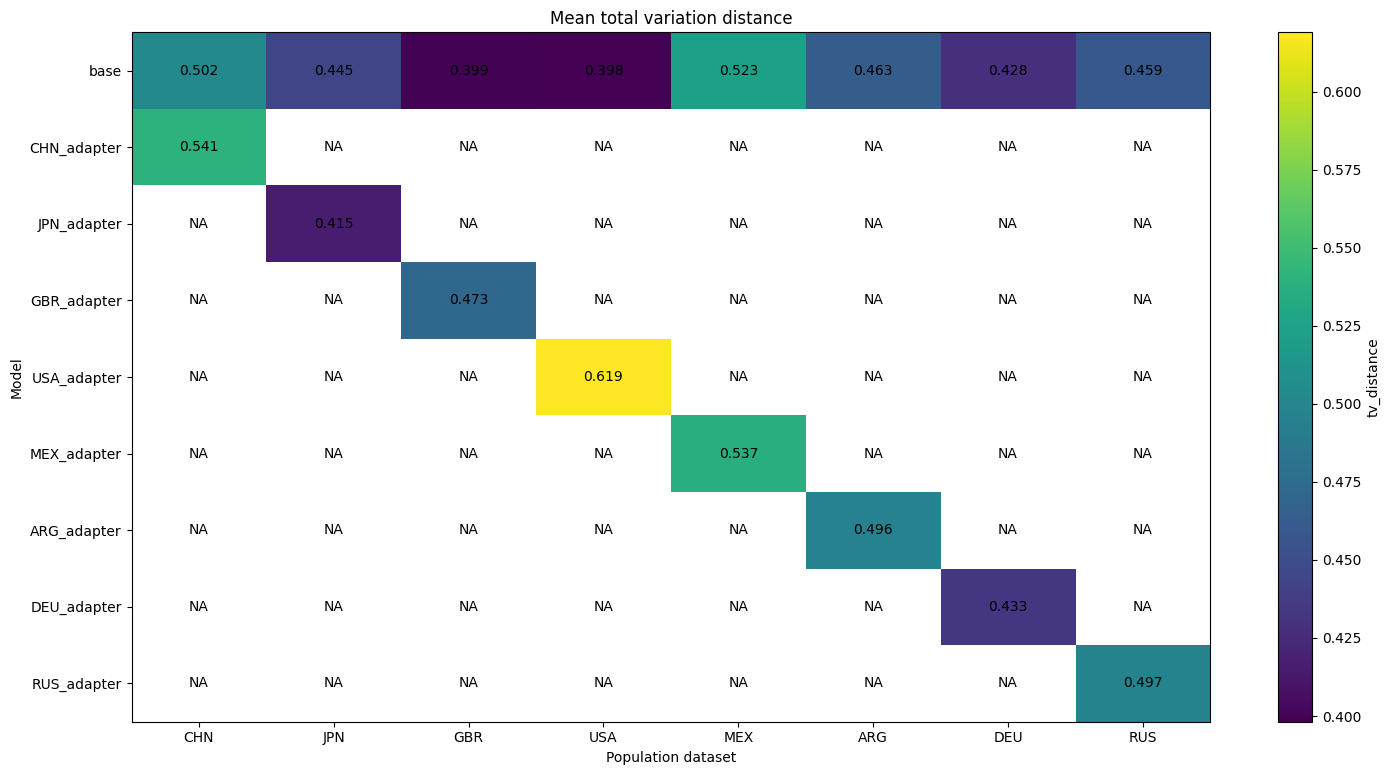

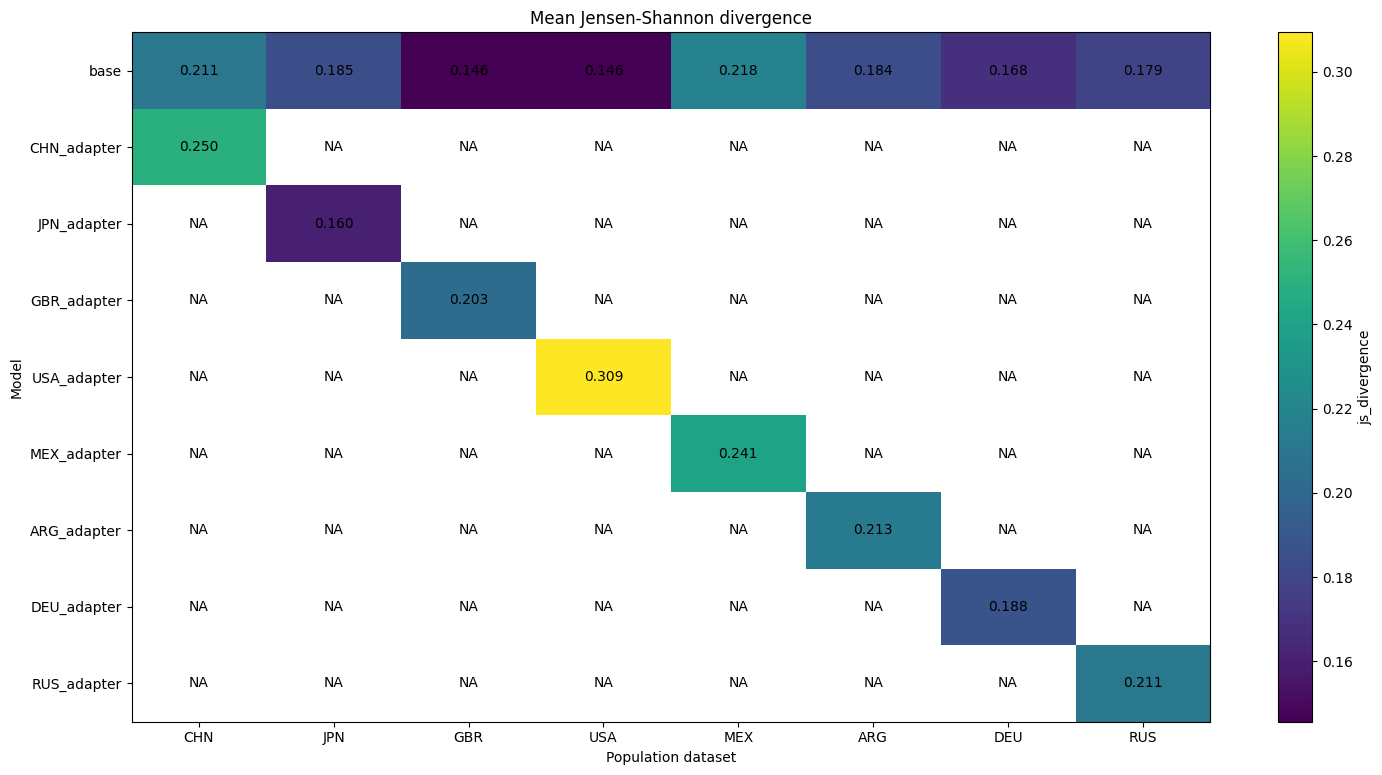

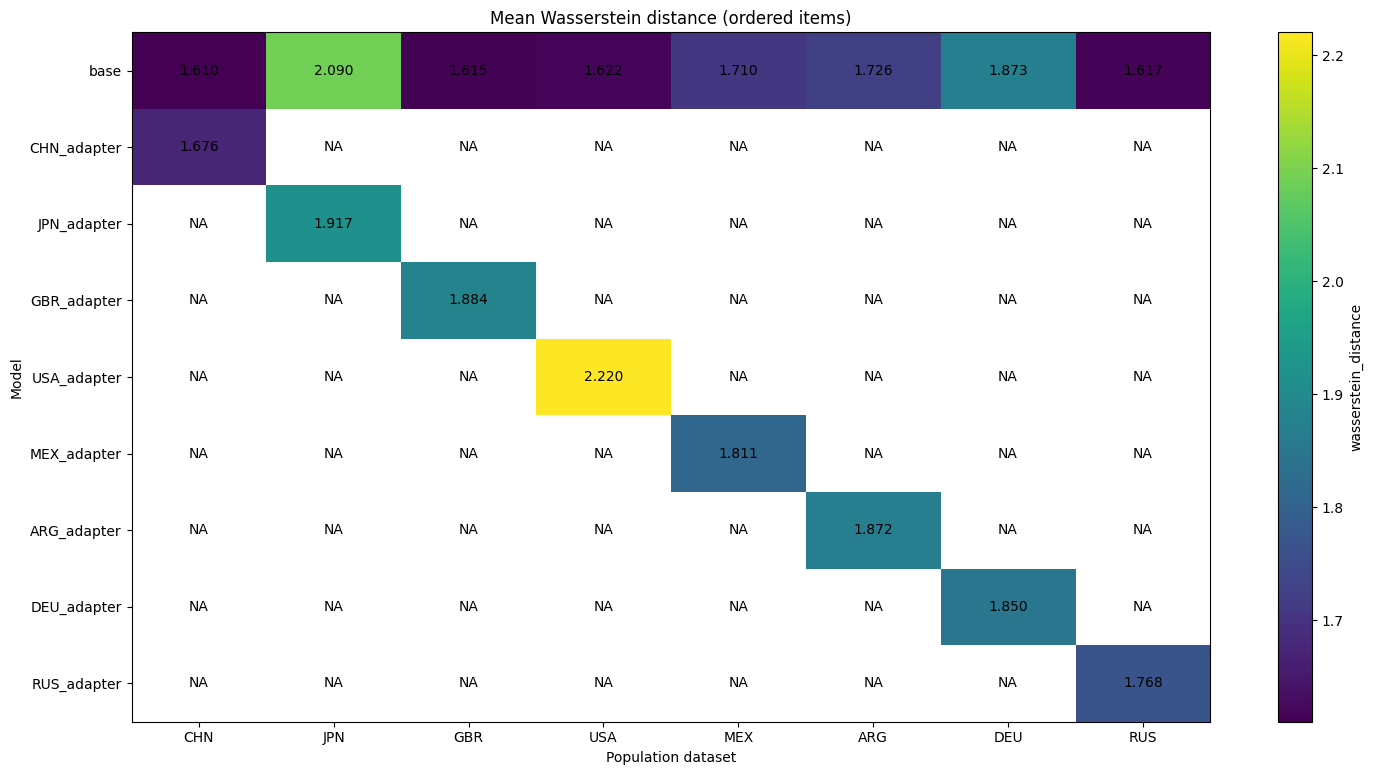

In [22]:
def plot_metric_heatmap(summary, metric, title=None):
    metric_rows = summary.loc[summary["metric"].eq(metric)].copy()
    if metric_rows.empty:
        print(f"No results available for {metric}.")
        return

    table = metric_rows.pivot_table(
        index="model", columns="eval_country", values="mean", aggfunc="mean"
    )
    if table.empty:
        print(f"No results available for {metric}.")
        return

    preferred_models = ["base"] + [
        f"{country}_adapter" for country in ADAPTER_COUNTRY_CODES
    ]
    ordered_models = [m for m in preferred_models if m in table.index]
    ordered_models += [m for m in table.index if m not in ordered_models]

    ordered_countries = [c for c in DATA_COUNTRY_CODES if c in table.columns]
    ordered_countries += [c for c in table.columns if c not in ordered_countries]

    table = table.reindex(index=ordered_models, columns=ordered_countries)

    fig_width = max(7.0, 1.5 * len(table.columns) + 3.0)
    fig_height = max(4.0, 0.65 * len(table.index) + 2.0)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(table.to_numpy(dtype=float), aspect="auto")
    ax.set_xticks(range(len(table.columns)), labels=table.columns)
    ax.set_yticks(range(len(table.index)), labels=table.index)
    ax.set_xlabel("Population dataset")
    ax.set_ylabel("Model")
    ax.set_title(title or metric)

    for row_index in range(len(table.index)):
        for column_index in range(len(table.columns)):
            value = table.iloc[row_index, column_index]
            label = "NA" if pd.isna(value) else f"{value:.3f}"
            ax.text(column_index, row_index, label, ha="center", va="center")

    fig.colorbar(image, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()


plot_metric_heatmap(bootstrap_summary, "tv_distance", "Mean total variation distance")
plot_metric_heatmap(bootstrap_summary, "js_divergence", "Mean Jensen-Shannon divergence")
plot_metric_heatmap(bootstrap_summary, "wasserstein_distance", "Mean Wasserstein distance (ordered items)")


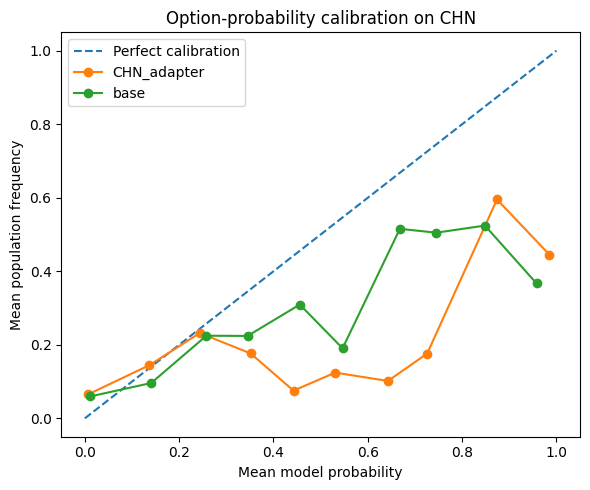

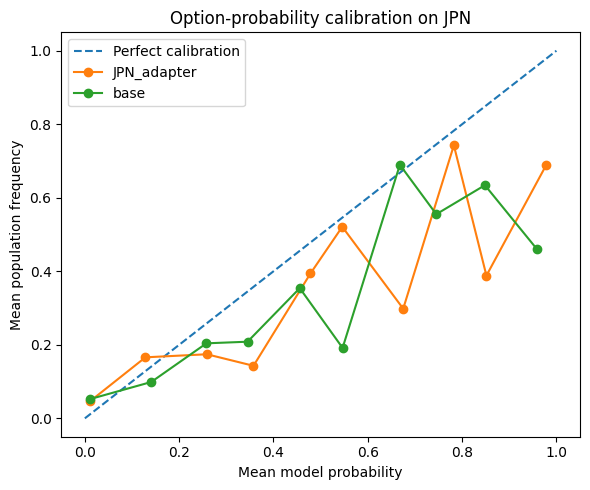

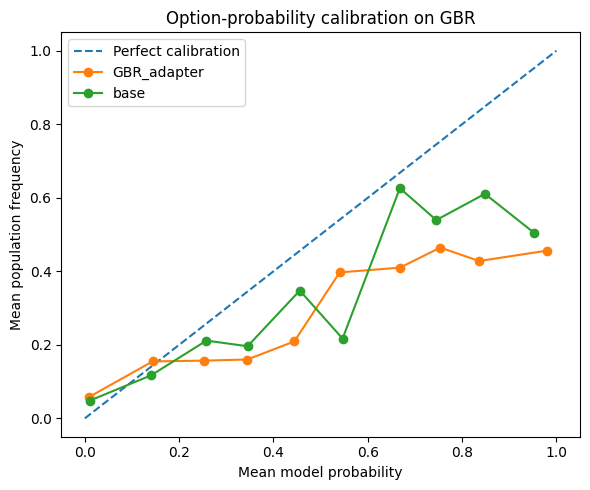

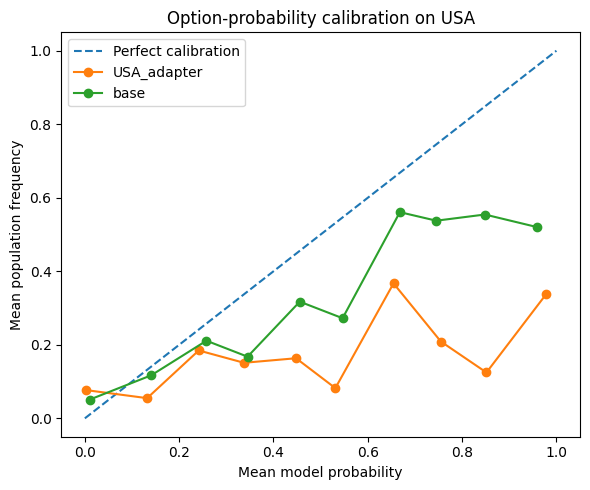

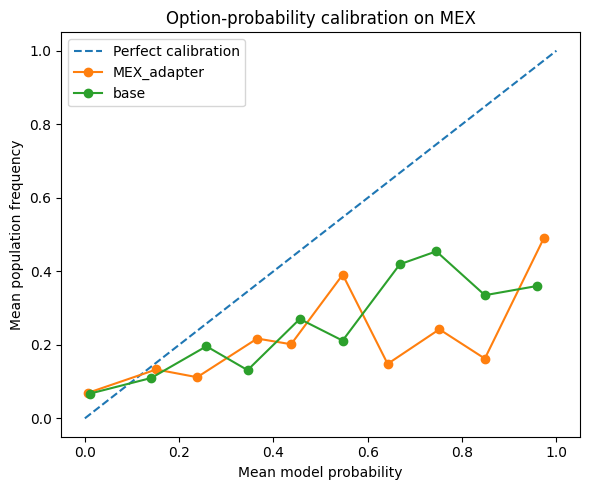

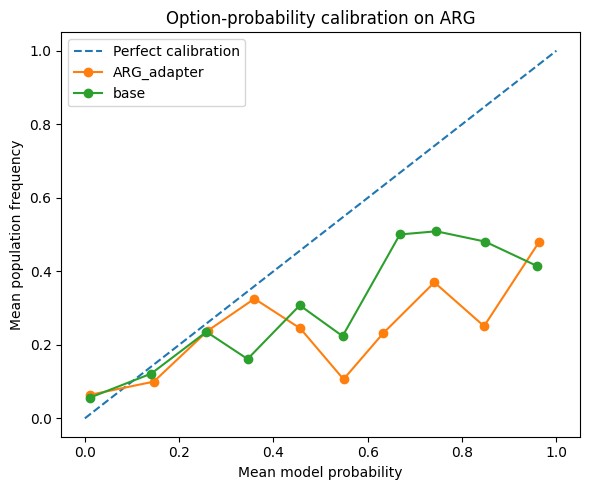

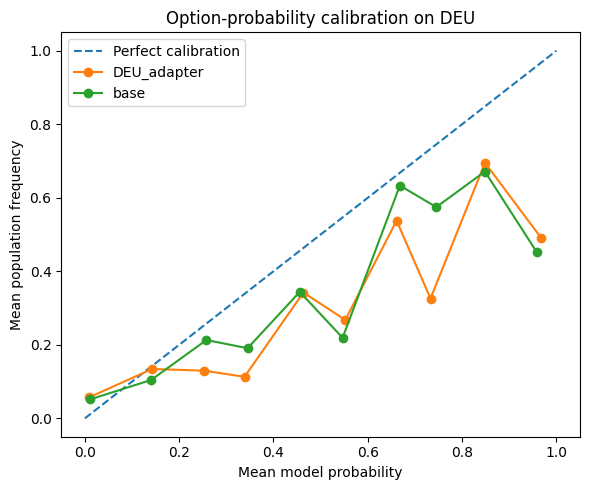

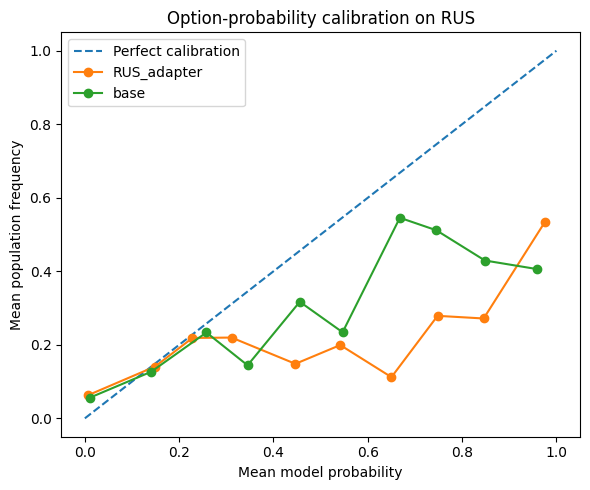

In [23]:
def plot_calibration(calibration_table):
    available_countries = [
        country
        for country in DATA_COUNTRY_CODES
        if country in set(calibration_table["eval_country"].dropna())
    ]

    for eval_country in available_countries:
        subset = calibration_table.loc[calibration_table["eval_country"].eq(eval_country)]
        if subset.empty:
            continue

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

        for model_name, model_group in subset.groupby("model"):
            ax.plot(
                model_group["mean_predicted_probability"],
                model_group["mean_population_probability"],
                marker="o",
                label=model_name,
            )

        ax.set_xlabel("Mean model probability")
        ax.set_ylabel("Mean population frequency")
        ax.set_title(f"Option-probability calibration on {eval_country}")
        ax.legend()
        plt.tight_layout()
        plt.show()


plot_calibration(calibration_table)


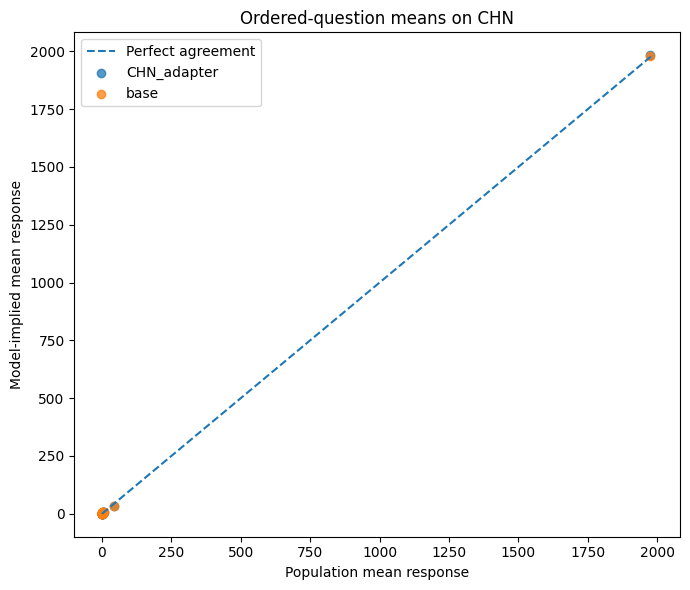

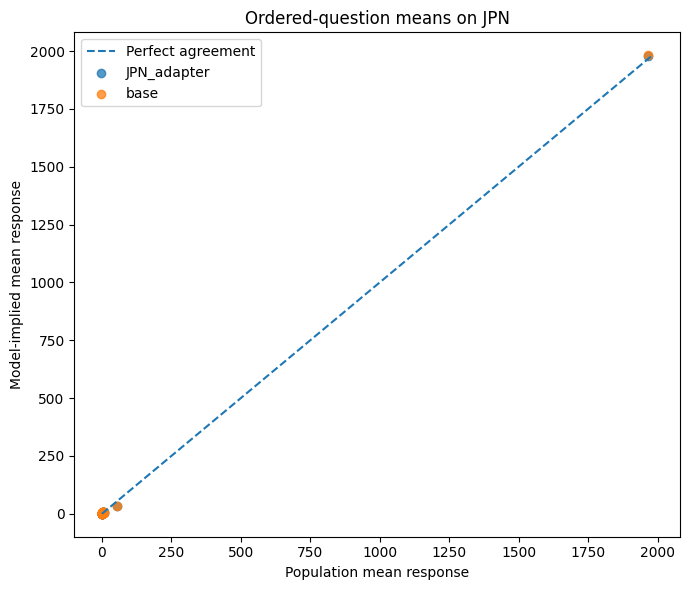

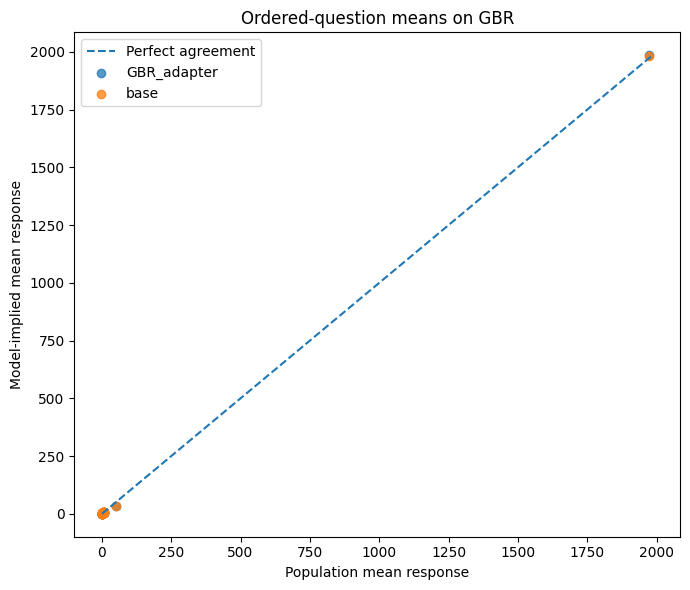

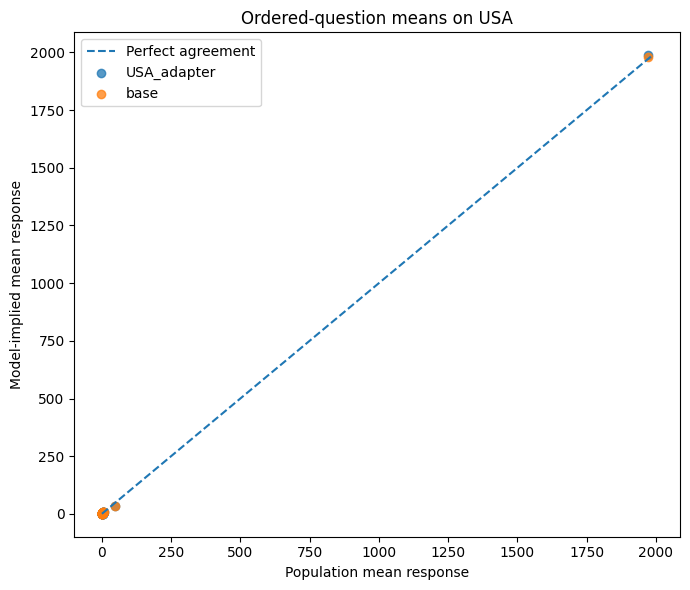

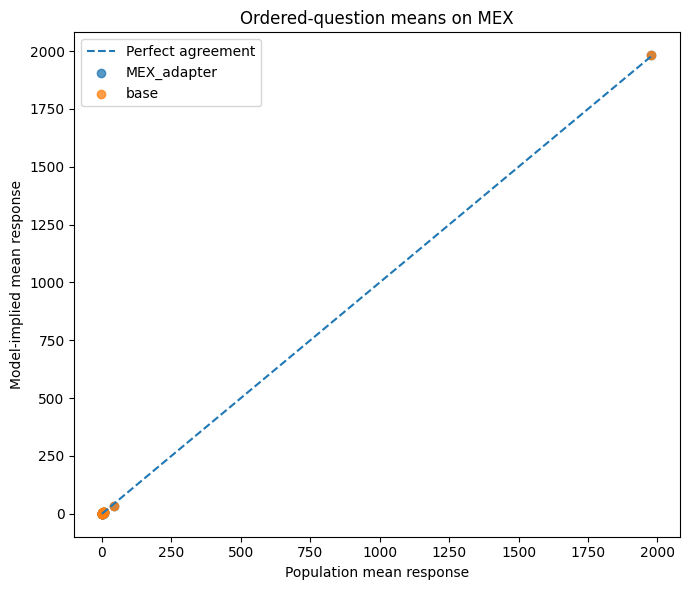

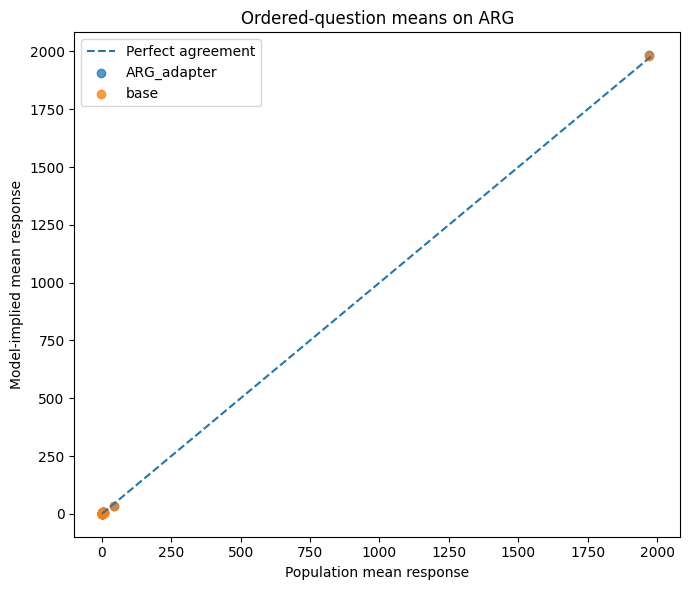

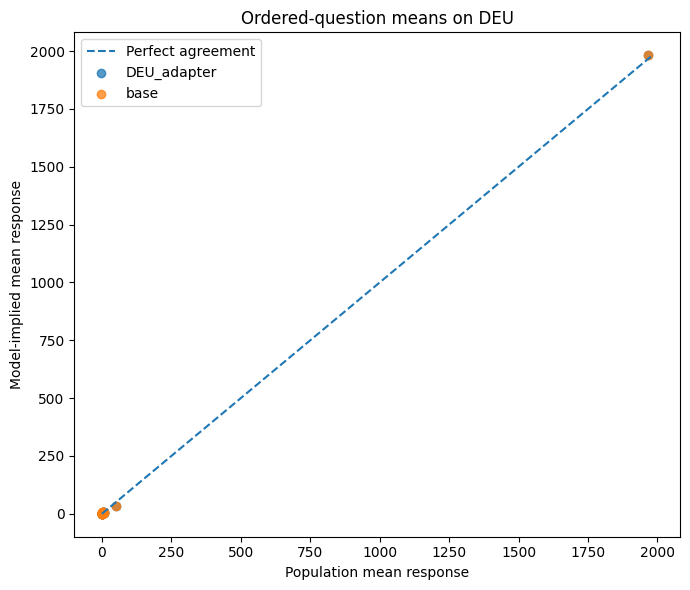

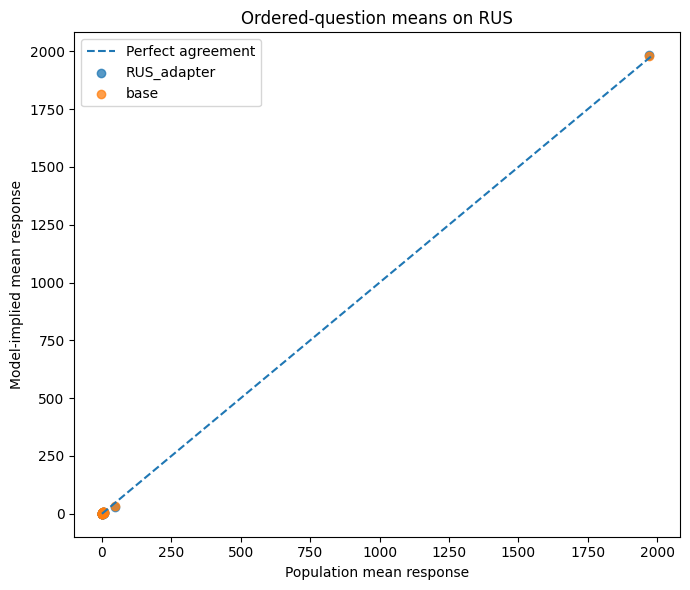

In [24]:
def plot_ordered_mean_scatter(question_metrics):
    ordered = question_metrics.loc[question_metrics["is_ordered"]].copy()

    available_countries = [
        country
        for country in DATA_COUNTRY_CODES
        if country in set(ordered["eval_country"].dropna())
    ]

    for eval_country in available_countries:
        subset = ordered.loc[ordered["eval_country"].eq(eval_country)].copy()
        subset = subset.loc[
            np.isfinite(pd.to_numeric(subset["population_mean"], errors="coerce"))
            & np.isfinite(pd.to_numeric(subset["model_mean"], errors="coerce"))
        ]
        if subset.empty:
            continue

        fig, ax = plt.subplots(figsize=(7, 6))

        minimum = min(subset["population_mean"].min(), subset["model_mean"].min())
        maximum = max(subset["population_mean"].max(), subset["model_mean"].max())
        ax.plot([minimum, maximum], [minimum, maximum], linestyle="--", label="Perfect agreement")

        for model_name, model_group in subset.groupby("model"):
            ax.scatter(
                model_group["population_mean"],
                model_group["model_mean"],
                alpha=0.75,
                label=model_name,
            )

        ax.set_xlabel("Population mean response")
        ax.set_ylabel("Model-implied mean response")
        ax.set_title(f"Ordered-question means on {eval_country}")
        ax.legend()
        plt.tight_layout()
        plt.show()


plot_ordered_mean_scatter(question_metrics)


## Inspect individual question distributions

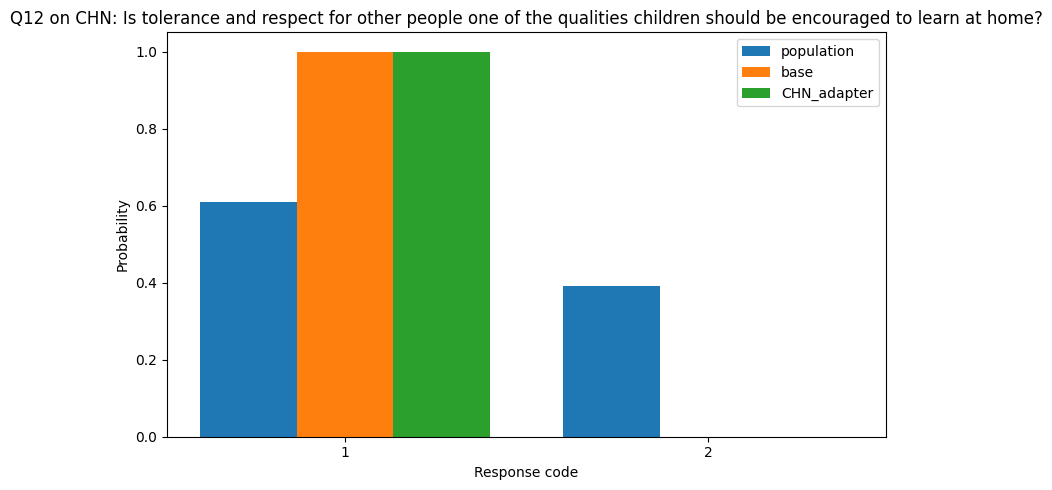

In [25]:
def plot_question_distribution(question_id, eval_country):
    subset = option_evaluation.loc[
        option_evaluation["question_id"].eq(question_id)
        & option_evaluation["eval_country"].eq(eval_country)
    ].copy()

    if subset.empty:
        print(
            f"No results found for {question_id} / {eval_country}. "
            "The question may be unavailable for that population dataset."
        )
        return

    first_model = subset["model"].iloc[0]
    population = subset.loc[subset["model"].eq(first_model)].sort_values("option_index")
    codes = population["option_code"].astype(str).tolist()
    x = np.arange(len(codes))

    preferred_models = ["base"] + [
        f"{country}_adapter" for country in ADAPTER_COUNTRY_CODES
    ]
    observed_models = subset["model"].drop_duplicates().tolist()
    model_names = [m for m in preferred_models if m in observed_models]
    model_names += [m for m in observed_models if m not in model_names]

    width = 0.8 / (len(model_names) + 1)

    fig, ax = plt.subplots(figsize=(max(8, len(codes) * 0.8), 5))
    ax.bar(x - 0.4 + width / 2, population["population_prob"], width=width, label="population")

    for model_index, model_name in enumerate(model_names, start=1):
        model_rows = subset.loc[subset["model"].eq(model_name)].copy()
        model_rows["option_code_str"] = model_rows["option_code"].astype(str)
        model_rows = model_rows.set_index("option_code_str").reindex(codes)
        ax.bar(
            x - 0.4 + width / 2 + model_index * width,
            model_rows["model_prob"].to_numpy(dtype=float),
            width=width,
            label=model_name,
        )

    ax.set_xticks(x, labels=codes)
    ax.set_xlabel("Response code")
    ax.set_ylabel("Probability")
    ax.set_title(f"{question_id} on {eval_country}: {population['question_text'].iloc[0]}")
    ax.legend()
    plt.tight_layout()
    plt.show()


# Example: choose the first country/question pair that actually has results.
if not option_evaluation.empty:
    example_pair = (
        option_evaluation[["eval_country", "question_id"]]
        .drop_duplicates()
        .iloc[0]
    )
    plot_question_distribution(
        example_pair["question_id"],
        example_pair["eval_country"],
    )

## Dimension analysis

In [26]:
# ============================================================
# Results analysis by GPS dimension
# ============================================================

required_columns = {
    "model",
    "eval_country",
    "relationship",
    "question_id",
    "gps_dimension",
    "tv_distance",
    "js_divergence",
    "brier_score",
    "cross_entropy",
    "wasserstein_distance",
    "abs_mean_error",
    "abs_std_error",
    "mean_error",
    "std_error",
    "top_option_match",
}

missing_columns = required_columns.difference(question_metrics.columns)
if missing_columns:
    raise ValueError(
        "question_metrics is missing required columns: "
        f"{sorted(missing_columns)}"
    )

gps_question_metrics = question_metrics.copy()

# Normalize missing or empty GPS-dimension labels.
gps_question_metrics["gps_dimension"] = (
    gps_question_metrics["gps_dimension"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
    .fillna("Unspecified")
)

GPS_ANALYSIS_METRICS = [
    "tv_distance",
    "js_divergence",
    "brier_score",
    "cross_entropy",
    "wasserstein_distance",
    "abs_mean_error",
    "abs_std_error",
]

In [27]:
# ------------------------------------------------------------
# 1. Absolute model performance by GPS dimension
# ------------------------------------------------------------

def summarize_metrics_by_gps_dimension(
    metrics_df,
    metric_columns=GPS_ANALYSIS_METRICS,
):
    rows = []

    grouping_columns = [
        "model",
        "eval_country",
        "relationship",
        "gps_dimension",
    ]

    for group_keys, group in metrics_df.groupby(
        grouping_columns,
        dropna=False,
        sort=False,
    ):
        model_name, eval_country, relationship, gps_dimension = group_keys

        for metric in metric_columns:
            values = pd.to_numeric(group[metric], errors="coerce")
            values = values[np.isfinite(values)]

            if values.empty:
                continue

            mean_value, ci_low, ci_high = bootstrap_mean_ci(
                values.to_numpy()
            )

            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                "gps_dimension": gps_dimension,
                "metric": metric,
                "mean": mean_value,
                "median": float(values.median()),
                "std_across_questions": (
                    float(values.std(ddof=1))
                    if len(values) > 1
                    else np.nan
                ),
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "n_questions": int(len(values)),
            })

    return pd.DataFrame(rows)


gps_dimension_metric_summary = summarize_metrics_by_gps_dimension(
    gps_question_metrics
)

gps_dimension_metric_summary.to_csv(
    RESULTS_DIR / "survey_metrics_by_gps_dimension_with_ci.csv",
    index=False,
)

primary_gps_metrics = gps_dimension_metric_summary[
    gps_dimension_metric_summary["metric"].isin([
        "tv_distance",
        "js_divergence",
        "wasserstein_distance",
        "abs_mean_error",
    ])
].copy()

display(
    primary_gps_metrics.sort_values([
        "gps_dimension",
        "eval_country",
        "metric",
        "mean",
    ])
)


# A wide table that makes model comparisons easier.
gps_performance_wide = (
    primary_gps_metrics
    .assign(
        condition=lambda df: (
            df["model"].astype(str)
            + "_on_"
            + df["eval_country"].astype(str)
        )
    )
    .pivot_table(
        index=["gps_dimension", "metric"],
        columns="condition",
        values="mean",
    )
    .reset_index()
)

gps_performance_wide.to_csv(
    RESULTS_DIR / "survey_metrics_by_gps_dimension_wide.csv",
    index=False,
)

display(gps_performance_wide)

,model,eval_country,relationship,gps_dimension,metric,mean,median,std_across_questions,ci_2.5%,ci_97.5%,n_questions
292,base,ARG,base,Unspecified,abs_mean_error,6.132853,6.486038,4.575079,2.310715,9.954990,4
684,ARG_adapter,ARG,matched,Unspecified,abs_mean_error,6.789615,7.346421,5.300972,2.302195,11.277035,4
288,base,ARG,base,Unspecified,js_divergence,0.264500,0.246439,0.219906,0.101531,0.442836,5
680,ARG_adapter,ARG,matched,Unspecified,js_divergence,0.298654,0.308823,0.227267,0.123665,0.470691,5
287,base,ARG,base,Unspecified,tv_distance,0.538104,0.575303,0.342183,0.254650,0.790571,5
...,...,...,...,...,...,...,...,...,...,...,...
554,USA_adapter,USA,matched,trust,js_divergence,0.251946,0.232317,0.104592,0.198699,0.313424,12
161,base,USA,base,trust,tv_distance,0.262653,0.250553,0.107234,0.204182,0.322169,12
553,USA_adapter,USA,matched,trust,tv_distance,0.539651,0.532643,0.185606,0.444091,0.641992,12
165,base,USA,base,trust,wasserstein_distance,0.332207,0.306347,0.161728,0.246749,0.424215,12


condition,gps_dimension,metric,ARG_adapter_on_ARG,CHN_adapter_on_CHN,DEU_adapter_on_DEU,GBR_adapter_on_GBR,JPN_adapter_on_JPN,MEX_adapter_on_MEX,RUS_adapter_on_RUS,USA_adapter_on_USA,base_on_ARG,base_on_CHN,base_on_DEU,base_on_GBR,base_on_JPN,base_on_MEX,base_on_RUS,base_on_USA
0,Unspecified,abs_mean_error,6.789615,5.035242,8.743726,7.633512,9.788224,4.927212,6.655670,8.268553,6.132853,5.137653,8.792079,6.785179,10.550534,4.718644,6.018814,6.712425
1,Unspecified,js_divergence,0.298654,0.313930,0.281663,0.298155,0.269308,0.283156,0.314443,0.383540,0.264500,0.251311,0.248297,0.240561,0.277641,0.254300,0.258496,0.225887
2,Unspecified,tv_distance,0.580037,0.651697,0.571962,0.600621,0.574402,0.578059,0.629572,0.732811,0.538104,0.540541,0.525452,0.535007,0.565767,0.545082,0.530640,0.501780
3,Unspecified,wasserstein_distance,7.972285,6.243189,9.439050,8.981816,10.162389,6.678082,7.812008,9.573353,7.275048,5.952452,9.244233,7.925864,10.906027,5.967788,6.871277,7.457242
4,altruism,abs_mean_error,1.523371,0.829326,0.014965,1.598712,0.195566,0.203114,0.028855,1.672118,0.969462,1.006377,0.900615,0.801915,1.024007,0.823679,1.034215,0.737326
5,altruism,js_divergence,0.420977,0.298640,0.003430,0.435469,0.038387,0.034771,0.006194,0.532695,0.213247,0.245421,0.174202,0.135021,0.259409,0.145329,0.264724,0.113227
6,altruism,tv_distance,0.809306,0.582758,0.036621,0.830951,0.148399,0.150651,0.023007,0.899801,0.556616,0.586291,0.525396,0.458679,0.603757,0.452577,0.608137,0.405036
7,altruism,wasserstein_distance,1.523371,0.829326,0.039538,1.598712,0.196803,0.203114,0.028855,1.672118,0.969462,1.006377,0.900615,0.801915,1.024007,0.823679,1.034215,0.737326
8,negrecip,abs_mean_error,1.360590,1.442724,0.875328,0.715214,0.887326,1.657818,1.191409,0.523541,1.342291,0.630152,1.026445,0.407703,0.679237,1.529158,1.030282,0.349963
9,negrecip,js_divergence,0.161262,0.186662,0.202295,0.167482,0.143190,0.267355,0.207770,0.233227,0.164657,0.167646,0.181926,0.130860,0.129437,0.201647,0.149206,0.137660


In [28]:

# ------------------------------------------------------------
# 2. Adapter improvement over the base model by GPS dimension
#
# Positive improvement means the adapter has LOWER error than
# the base model on the same questions and population.
# ------------------------------------------------------------

def compare_adapters_with_base_by_gps(metrics_df):
    base_columns = [
        "eval_country",
        "question_id",
        "gps_dimension",
    ] + GPS_ANALYSIS_METRICS

    base = metrics_df.loc[
        metrics_df["model"].eq("base"),
        base_columns,
    ].copy()

    base = base.rename(columns={
        metric: f"base_{metric}"
        for metric in GPS_ANALYSIS_METRICS
    })

    adapters = metrics_df.loc[
        metrics_df["model"].ne("base")
    ].copy()

    comparison = adapters.merge(
        base,
        on=[
            "eval_country",
            "question_id",
            "gps_dimension",
        ],
        how="inner",
        validate="many_to_one",
    )

    for metric in GPS_ANALYSIS_METRICS:
        comparison[f"improvement_{metric}"] = (
            comparison[f"base_{metric}"] - comparison[metric]
        )

    return comparison


def summarize_gps_base_improvements(comparison_df):
    rows = []

    grouping_columns = [
        "model",
        "eval_country",
        "relationship",
        "gps_dimension",
    ]

    for group_keys, group in comparison_df.groupby(
        grouping_columns,
        dropna=False,
        sort=False,
    ):
        model_name, eval_country, relationship, gps_dimension = group_keys

        for metric in GPS_ANALYSIS_METRICS:
            improvement_column = f"improvement_{metric}"

            values = pd.to_numeric(
                group[improvement_column],
                errors="coerce",
            )
            values = values[np.isfinite(values)]

            if values.empty:
                continue

            mean_value, ci_low, ci_high = bootstrap_mean_ci(
                values.to_numpy()
            )

            rows.append({
                "model": model_name,
                "eval_country": eval_country,
                "relationship": relationship,
                "gps_dimension": gps_dimension,
                "metric": metric,
                "mean_improvement_over_base": mean_value,
                "median_improvement_over_base": float(values.median()),
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "fraction_questions_improved": float(
                    (values > 0).mean()
                ),
                "n_questions": int(len(values)),
            })

    columns = [
        "model", "eval_country", "relationship", "gps_dimension", "metric",
        "mean_improvement_over_base", "median_improvement_over_base",
        "ci_2.5%", "ci_97.5%", "fraction_questions_improved", "n_questions",
    ]
    return pd.DataFrame(rows, columns=columns)


gps_base_comparison_by_question = (
    compare_adapters_with_base_by_gps(gps_question_metrics)
)

gps_base_improvement_summary = summarize_gps_base_improvements(
    gps_base_comparison_by_question
)

gps_base_comparison_by_question.to_csv(
    RESULTS_DIR
    / "survey_adapter_improvement_vs_base_by_question_and_gps_dimension.csv",
    index=False,
)

gps_base_improvement_summary.to_csv(
    RESULTS_DIR
    / "survey_adapter_improvement_vs_base_by_gps_dimension.csv",
    index=False,
)

display(
    gps_base_improvement_summary[
        gps_base_improvement_summary["metric"].isin([
            "tv_distance",
            "js_divergence",
            "wasserstein_distance",
            "abs_mean_error",
        ])
    ].sort_values([
        "gps_dimension",
        "eval_country",
        "metric",
        "mean_improvement_over_base",
    ], ascending=[True, True, True, False])
)



,model,eval_country,relationship,gps_dimension,metric,mean_improvement_over_base,median_improvement_over_base,ci_2.5%,ci_97.5%,fraction_questions_improved,n_questions
292,ARG_adapter,ARG,matched,Unspecified,abs_mean_error,-0.656762,-0.467027,-1.322044,0.008520,0.250000,4
288,ARG_adapter,ARG,matched,Unspecified,js_divergence,-0.034154,-0.032140,-0.059495,-0.010251,0.200000,5
287,ARG_adapter,ARG,matched,Unspecified,tv_distance,-0.041933,-0.065549,-0.077871,-0.003647,0.200000,5
291,ARG_adapter,ARG,matched,Unspecified,wasserstein_distance,-0.697237,-0.561657,-1.365077,-0.029397,0.000000,4
47,CHN_adapter,CHN,matched,Unspecified,abs_mean_error,0.102411,0.150652,-0.866884,1.023465,0.750000,4
...,...,...,...,...,...,...,...,...,...,...,...
361,RUS_adapter,RUS,matched,trust,wasserstein_distance,-0.157705,-0.143795,-0.295622,-0.018702,0.250000,12
166,USA_adapter,USA,matched,trust,abs_mean_error,-0.580654,-0.520881,-0.748036,-0.424611,0.000000,12
162,USA_adapter,USA,matched,trust,js_divergence,-0.184874,-0.149360,-0.246203,-0.129279,0.000000,12
161,USA_adapter,USA,matched,trust,tv_distance,-0.276998,-0.271304,-0.391762,-0.163675,0.166667,12


In [29]:
gps_base_improvement_summary.groupby(['model', 'eval_country'])[['mean_improvement_over_base',
                                                                 'median_improvement_over_base' ]].mean()

,,mean_improvement_over_base,median_improvement_over_base
model,eval_country,,
ARG_adapter,ARG,-0.194863,-0.183545
CHN_adapter,CHN,-0.249505,-0.265143
DEU_adapter,DEU,-0.020353,0.007792
GBR_adapter,GBR,-0.350833,-0.321968
JPN_adapter,JPN,0.147147,0.117585
MEX_adapter,MEX,-0.098723,-0.063131
RUS_adapter,RUS,-0.094876,-0.055071
USA_adapter,USA,-1.174181,-1.074111


In [30]:
gps_base_improvement_summary.groupby('relationship')[['mean_improvement_over_base','median_improvement_over_base' ]].mean()

,mean_improvement_over_base,median_improvement_over_base
relationship,,
matched,-0.254523,-0.229699


In [31]:
# ------------------------------------------------------------
# 3. Matched adapter versus cross-country adapter
#
# Positive specificity means the matched-country adapter has
# LOWER error than the average available cross-country adapter.
# If the selected setup has no cross-evaluation, these tables
# are saved empty and the remaining analysis continues.
# ------------------------------------------------------------

def matched_vs_cross_by_gps(metrics_df):
    adapter_metrics = metrics_df.loc[
        metrics_df["model"].ne("base")
    ].copy()

    matched = adapter_metrics.loc[
        adapter_metrics["relationship"].eq("matched")
    ].copy()

    cross = adapter_metrics.loc[
        adapter_metrics["relationship"].eq("cross")
    ].copy()

    key_columns = [
        "eval_country",
        "question_id",
        "gps_dimension",
    ]

    output_columns = key_columns.copy()
    output_columns += [f"matched_{metric}" for metric in GPS_ANALYSIS_METRICS]
    output_columns += [f"cross_{metric}" for metric in GPS_ANALYSIS_METRICS]
    output_columns += [f"specificity_{metric}" for metric in GPS_ANALYSIS_METRICS]

    if matched.empty or cross.empty:
        return pd.DataFrame(columns=output_columns)

    matched = matched[
        key_columns + GPS_ANALYSIS_METRICS
    ].rename(columns={
        metric: f"matched_{metric}"
        for metric in GPS_ANALYSIS_METRICS
    })

    # More than one cross adapter may have been selected for the same dataset.
    # Average the available cross adapters per question before comparing with
    # the matched adapter. With two countries this is identical to the original.
    cross = (
        cross.groupby(key_columns, as_index=False)[GPS_ANALYSIS_METRICS]
        .mean(numeric_only=True)
        .rename(columns={
            metric: f"cross_{metric}"
            for metric in GPS_ANALYSIS_METRICS
        })
    )

    comparison = matched.merge(
        cross,
        on=key_columns,
        how="inner",
        validate="one_to_one",
    )

    for metric in GPS_ANALYSIS_METRICS:
        comparison[f"specificity_{metric}"] = (
            comparison[f"cross_{metric}"]
            - comparison[f"matched_{metric}"]
        )

    return comparison.reindex(columns=output_columns)


def summarize_gps_specificity(comparison_df):
    columns = [
        "eval_country", "gps_dimension", "metric",
        "mean_cross_minus_matched", "median_cross_minus_matched",
        "ci_2.5%", "ci_97.5%", "fraction_questions_matched_better",
        "n_questions",
    ]
    rows = []

    for (eval_country, gps_dimension), group in comparison_df.groupby(
        ["eval_country", "gps_dimension"],
        dropna=False,
        sort=False,
    ):
        for metric in GPS_ANALYSIS_METRICS:
            specificity_column = f"specificity_{metric}"

            values = pd.to_numeric(
                group[specificity_column],
                errors="coerce",
            )
            values = values[np.isfinite(values)]

            if values.empty:
                continue

            mean_value, ci_low, ci_high = bootstrap_mean_ci(
                values.to_numpy()
            )

            rows.append({
                "eval_country": eval_country,
                "gps_dimension": gps_dimension,
                "metric": metric,
                "mean_cross_minus_matched": mean_value,
                "median_cross_minus_matched": float(values.median()),
                "ci_2.5%": ci_low,
                "ci_97.5%": ci_high,
                "fraction_questions_matched_better": float(
                    (values > 0).mean()
                ),
                "n_questions": int(len(values)),
            })

    return pd.DataFrame(rows, columns=columns)


gps_specificity_by_question = matched_vs_cross_by_gps(
    gps_question_metrics
)

gps_specificity_summary = summarize_gps_specificity(
    gps_specificity_by_question
)

gps_specificity_by_question.to_csv(
    RESULTS_DIR
    / "survey_matched_vs_cross_specificity_by_question_and_gps_dimension.csv",
    index=False,
)

gps_specificity_summary.to_csv(
    RESULTS_DIR
    / "survey_matched_vs_cross_specificity_by_gps_dimension.csv",
    index=False,
)

if gps_specificity_summary.empty:
    print("No GPS matched-versus-cross comparisons are available for the selected evaluation setup.")
else:
    display(
        gps_specificity_summary[
            gps_specificity_summary["metric"].isin([
                "tv_distance",
                "js_divergence",
                "wasserstein_distance",
                "abs_mean_error",
            ])
        ].sort_values([
            "gps_dimension",
            "eval_country",
            "metric",
        ])
    )


No GPS matched-versus-cross comparisons are available for the selected evaluation setup.


In [32]:
# ------------------------------------------------------------
# 4. Mean, dispersion, entropy and top-option diagnostics
# ------------------------------------------------------------

gps_moment_summary = (
    gps_question_metrics
    .groupby([
        "model",
        "eval_country",
        "relationship",
        "gps_dimension",
    ], dropna=False, as_index=False)
    .agg(
        mean_response_bias=("mean_error", "mean"),
        median_response_bias=("mean_error", "median"),
        mean_absolute_response_error=("abs_mean_error", "mean"),
        mean_dispersion_bias=("std_error", "mean"),
        median_dispersion_bias=("std_error", "median"),
        mean_absolute_dispersion_error=("abs_std_error", "mean"),
        mean_entropy_bias=("entropy_error", "mean"),
        top_option_match_rate=("top_option_match", "mean"),
        n_questions=("question_id", "nunique"),
        n_ordered_questions=("mean_error", "count"),
    )
)

gps_moment_summary.to_csv(
    RESULTS_DIR / "survey_moment_diagnostics_by_gps_dimension.csv",
    index=False,
)

display(
    gps_moment_summary.sort_values([
        "gps_dimension",
        "eval_country",
        "model",
    ])
)


,model,eval_country,relationship,gps_dimension,mean_response_bias,median_response_bias,mean_absolute_response_error,mean_dispersion_bias,median_dispersion_bias,mean_absolute_dispersion_error,mean_entropy_bias,top_option_match_rate,n_questions,n_ordered_questions
0,ARG_adapter,ARG,matched,Unspecified,1.033188,2.302195,6.789615,-6.934001,-5.847453,6.934001,-1.160352,0.000000,5,4
56,base,ARG,base,Unspecified,0.840770,2.310715,6.132853,-6.134478,-5.001025,6.134478,-0.962836,0.200000,5,4
7,CHN_adapter,CHN,matched,Unspecified,1.249463,2.478943,5.035242,-4.961104,-4.177244,4.961104,-1.318731,0.200000,5,4
63,base,CHN,base,Unspecified,0.672970,2.629595,5.137653,-4.175077,-3.064877,4.175077,-0.894704,0.200000,5,4
14,DEU_adapter,DEU,matched,Unspecified,0.319711,1.270772,8.743726,-6.550031,-5.627924,6.550031,-1.229723,0.200000,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,base,MEX,base,trust,-0.672655,-0.854967,0.721271,-0.380759,-0.393514,0.403557,-0.479106,0.166667,12,12
48,RUS_adapter,RUS,matched,trust,0.066633,0.231913,0.413663,-0.541888,-0.582949,0.541888,-0.828374,0.416667,12,12
104,base,RUS,base,trust,-0.268868,-0.240306,0.372081,-0.360207,-0.405355,0.370715,-0.514470,0.500000,12,12
55,USA_adapter,USA,matched,trust,-0.794062,-0.758814,0.794062,-0.429215,-0.450858,0.429215,-0.666693,0.250000,12,12


In [33]:
# ------------------------------------------------------------
# 5. Question counts per GPS dimension
# ------------------------------------------------------------

gps_question_counts = (
    gps_question_metrics[
        ["question_id", "gps_dimension", "response_type", "is_ordered"]
    ]
    .drop_duplicates()
    .groupby("gps_dimension", as_index=False)
    .agg(
        n_questions=("question_id", "nunique"),
        n_response_types=("response_type", "nunique"),
        n_ordered_questions=("is_ordered", "sum"),
    )
    .sort_values("gps_dimension")
)

gps_question_counts.to_csv(
    RESULTS_DIR / "survey_question_counts_by_gps_dimension.csv",
    index=False,
)

display(gps_question_counts)



,gps_dimension,n_questions,n_response_types,n_ordered_questions
0,Unspecified,5,4,4
1,altruism,3,1,3
2,negrecip,4,1,4
3,patience,4,3,4
4,posrecip,3,3,2
5,risktaking,4,1,4
6,trust,12,2,12


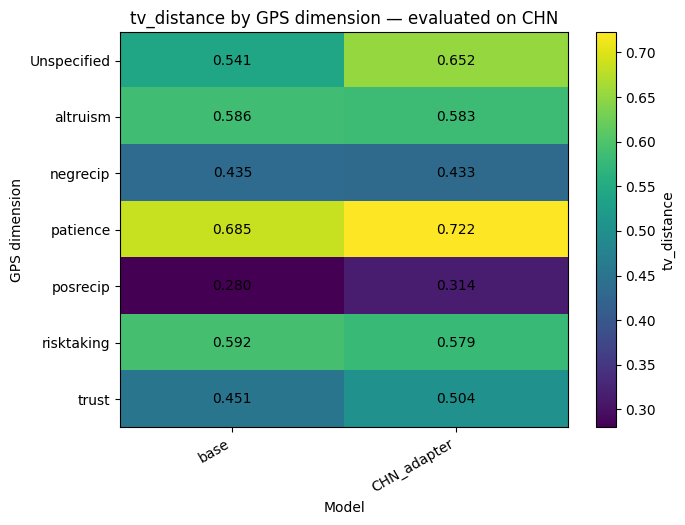

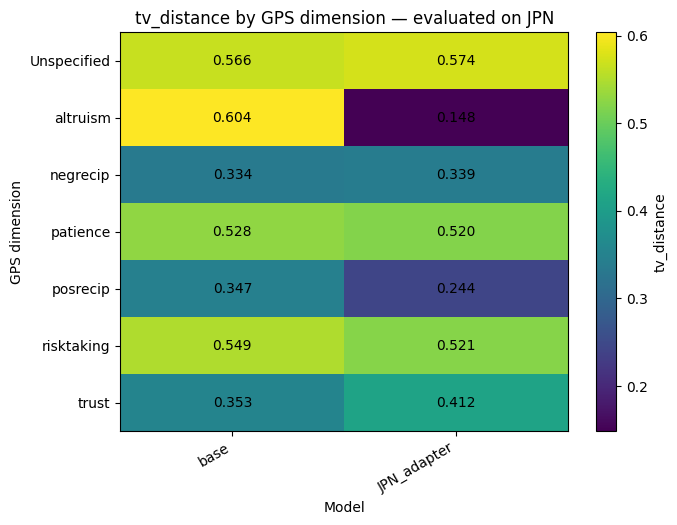

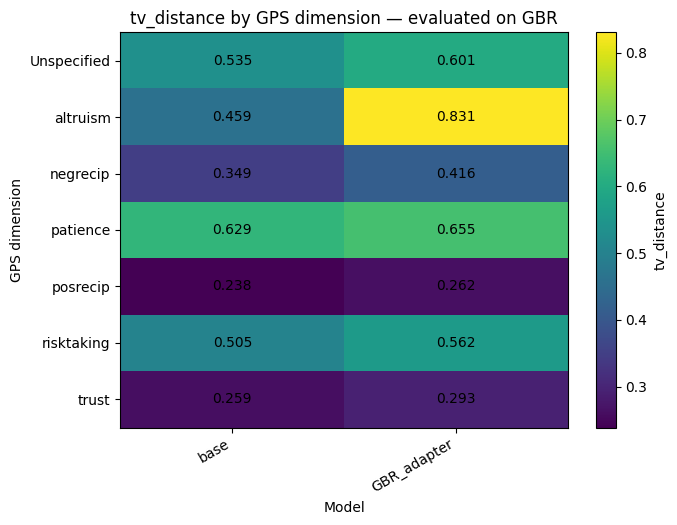

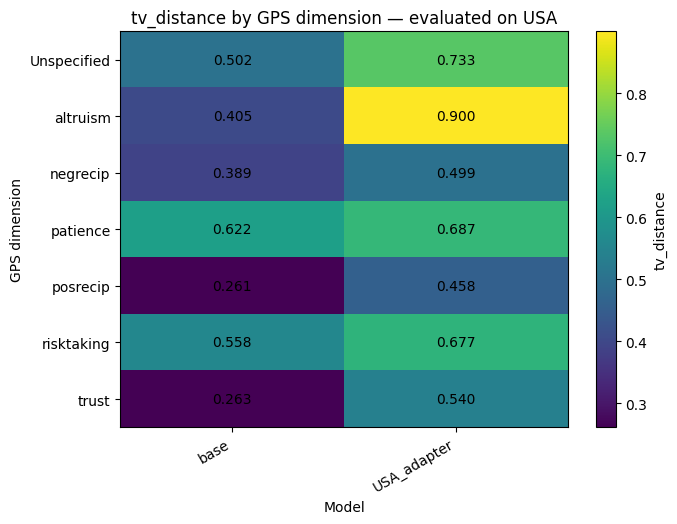

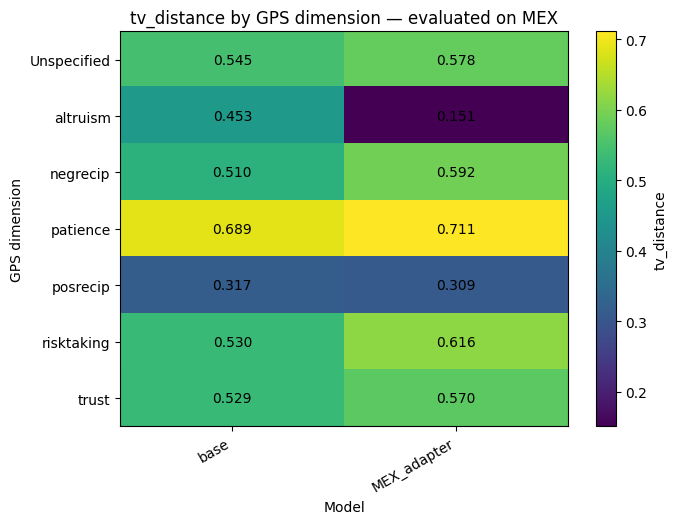

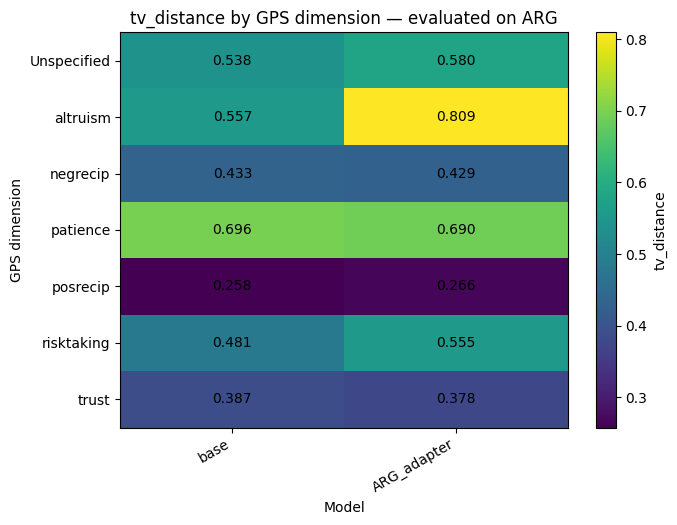

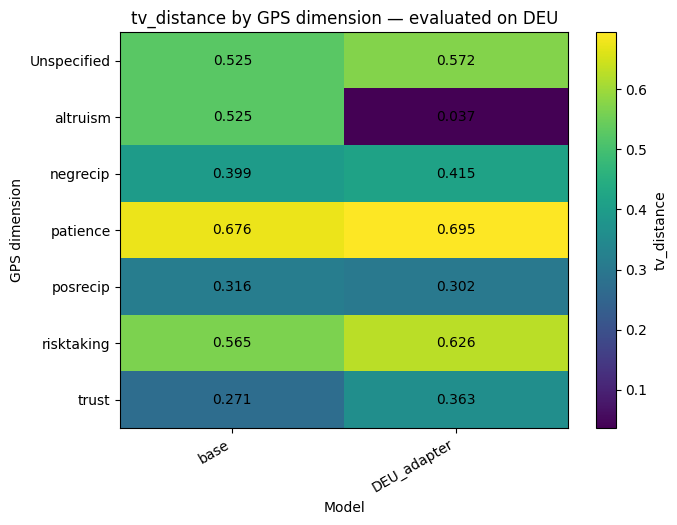

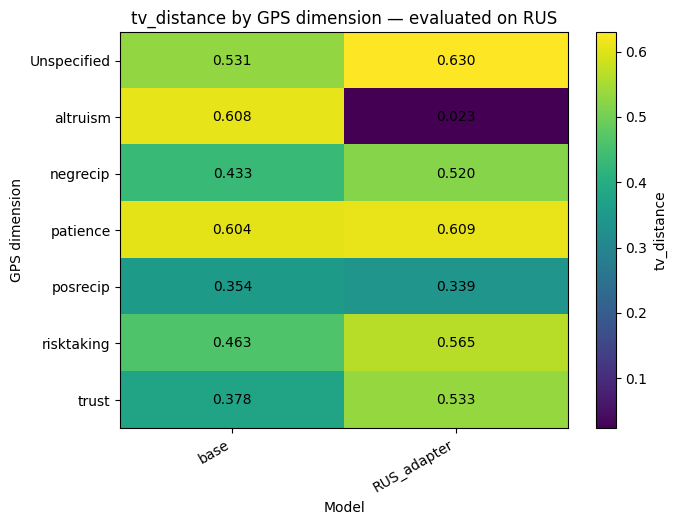

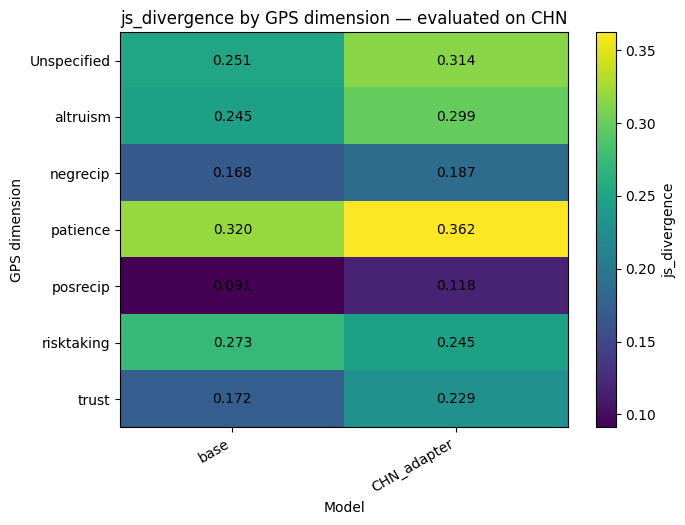

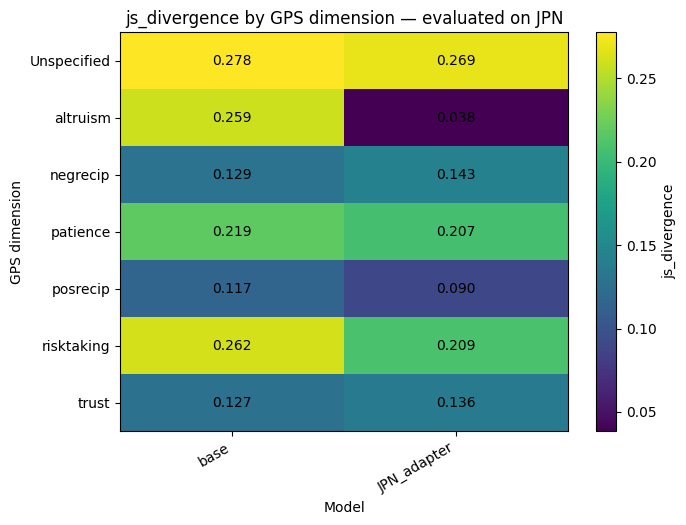

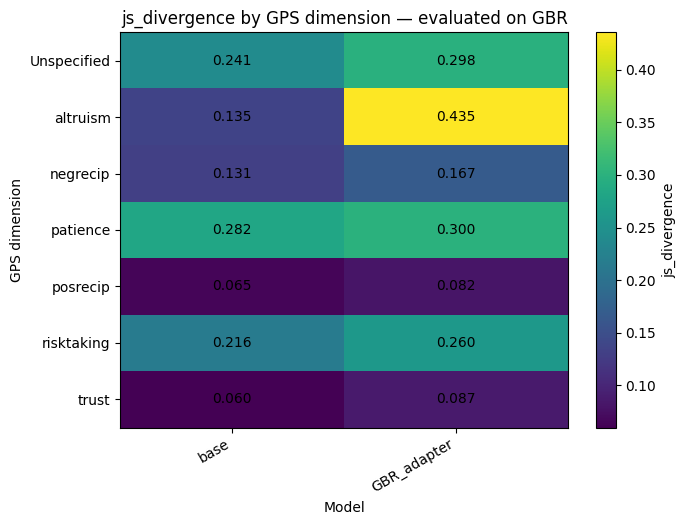

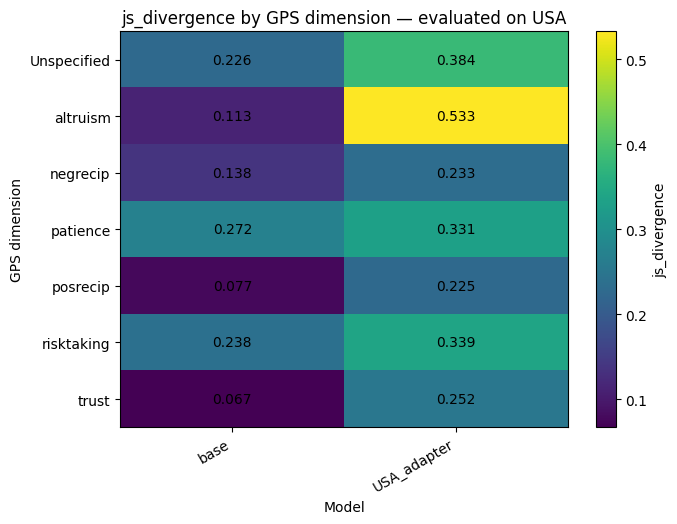

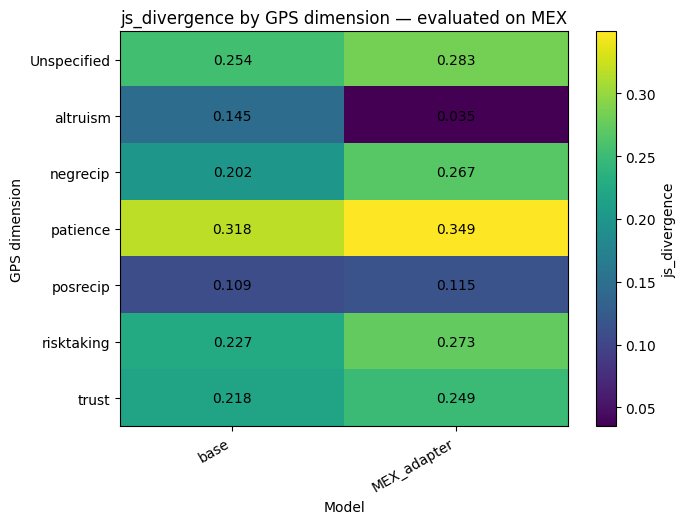

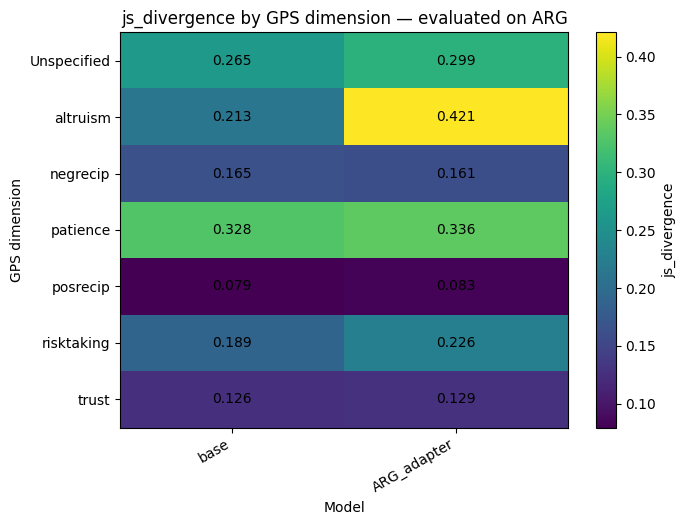

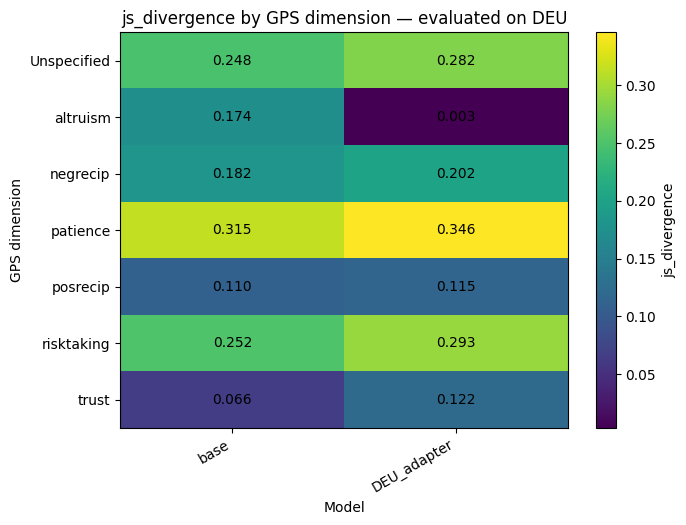

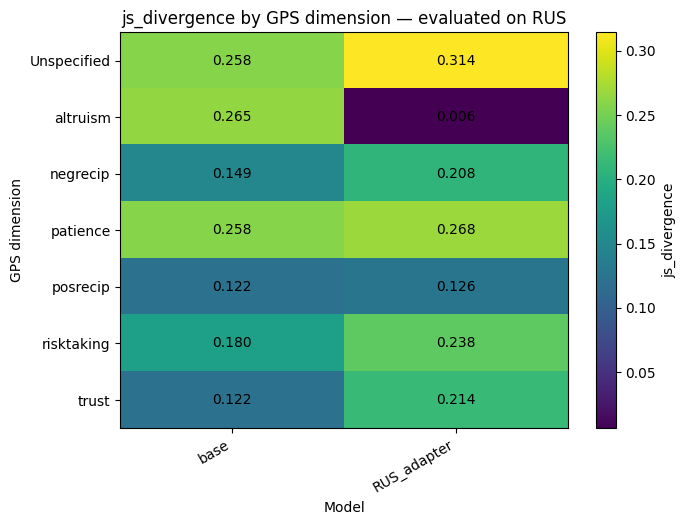

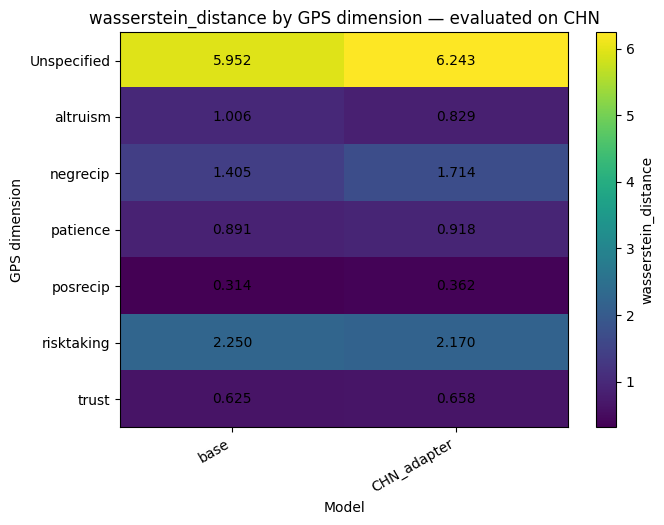

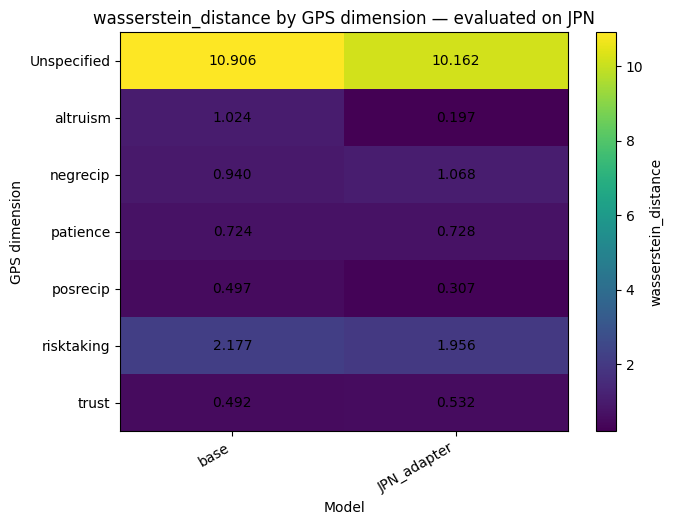

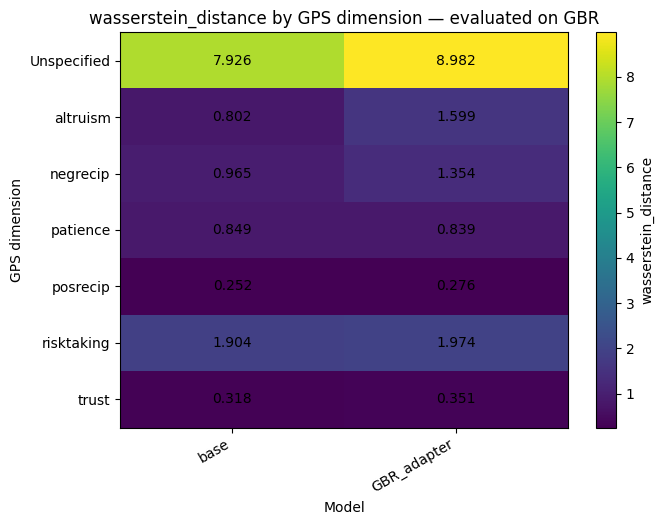

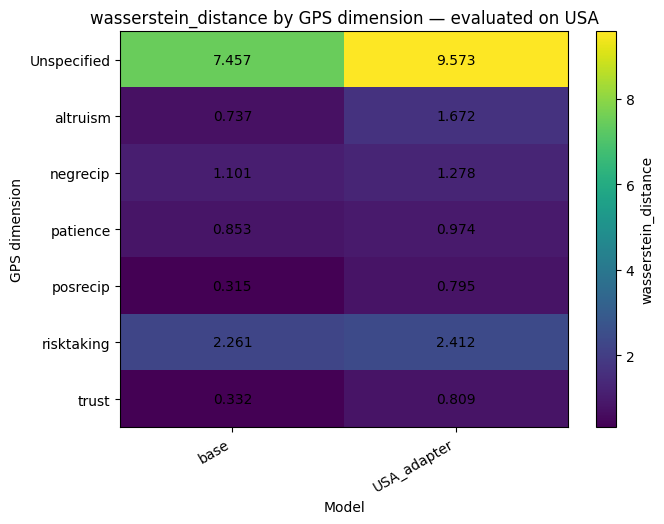

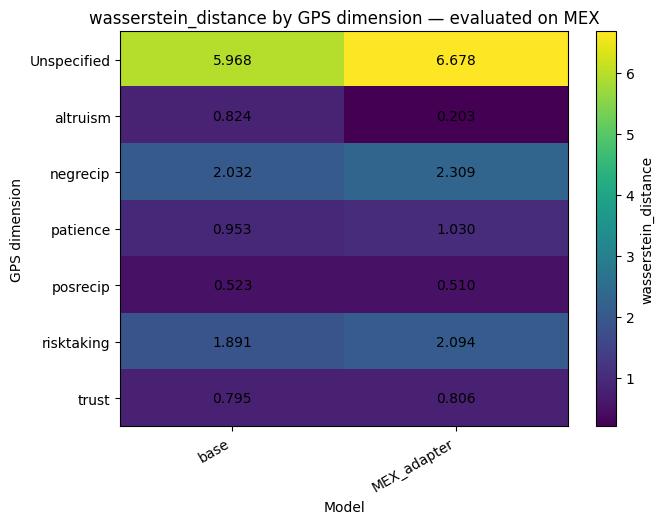

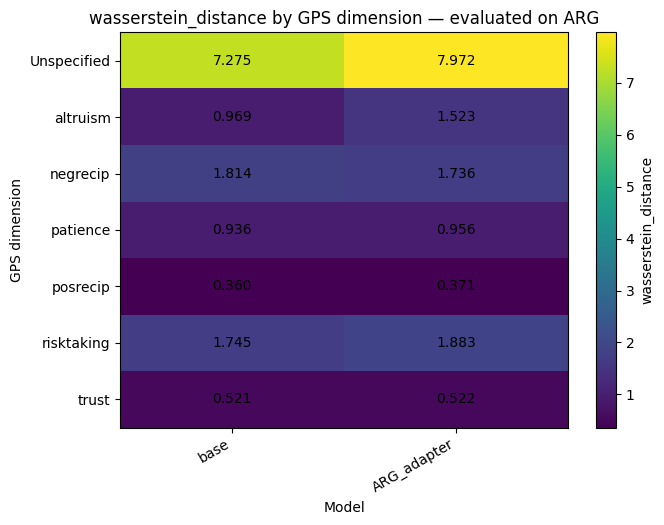

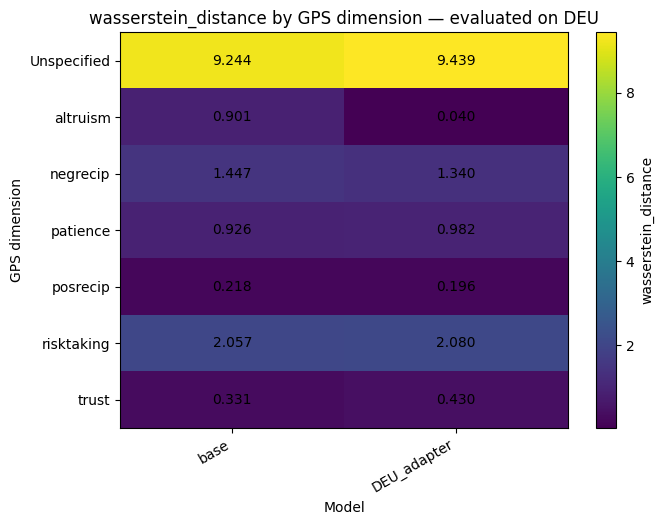

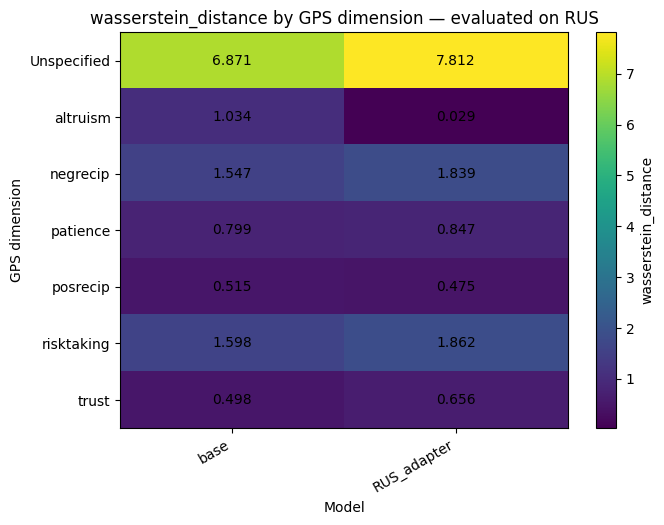

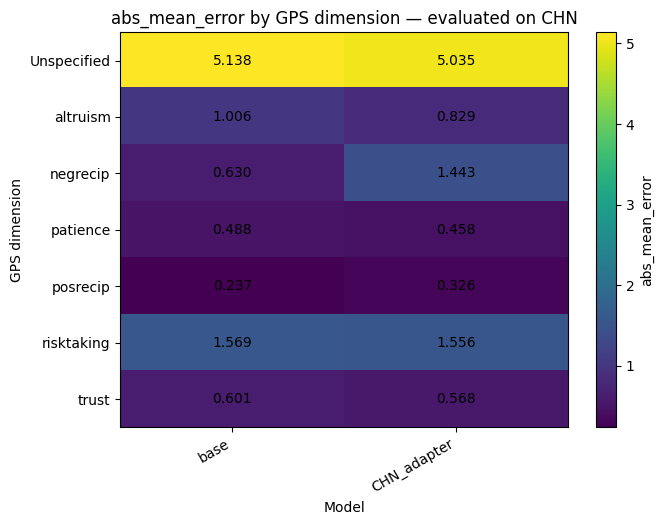

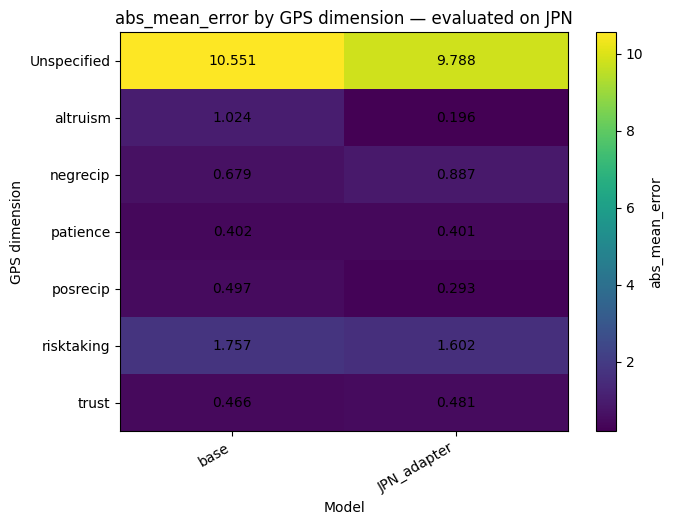

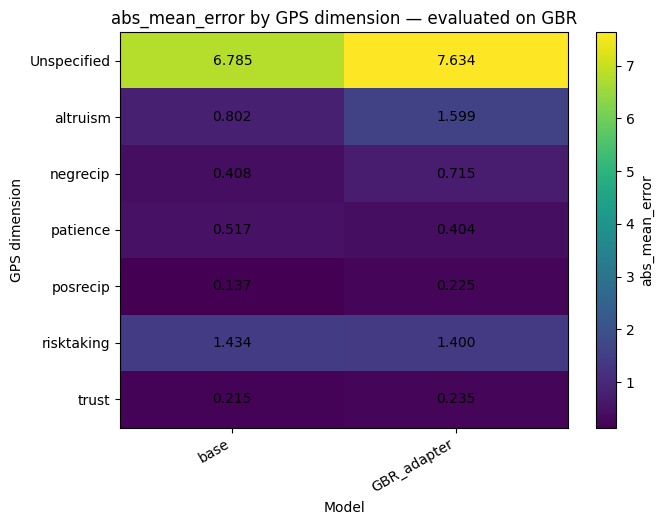

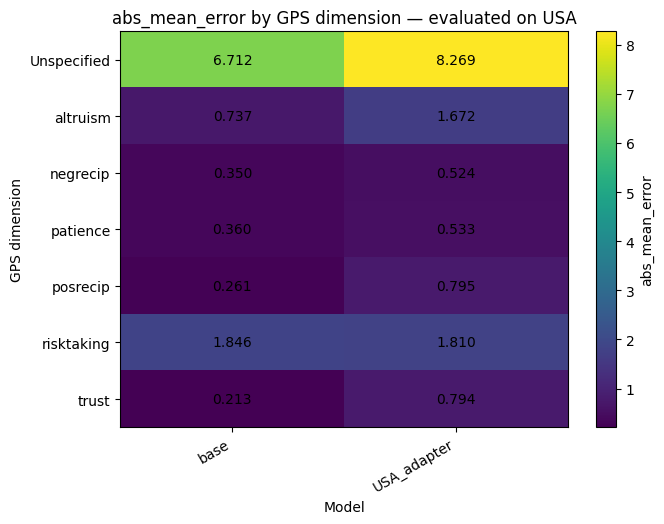

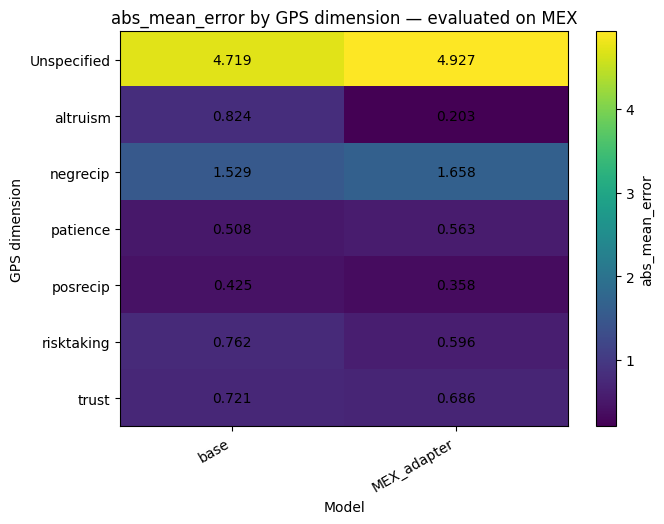

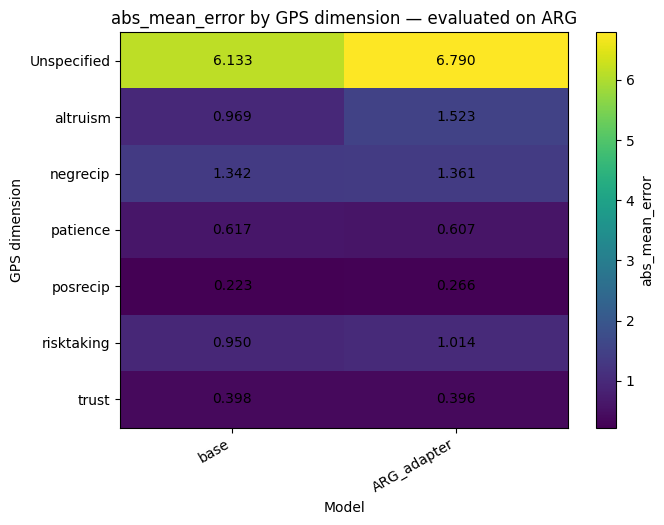

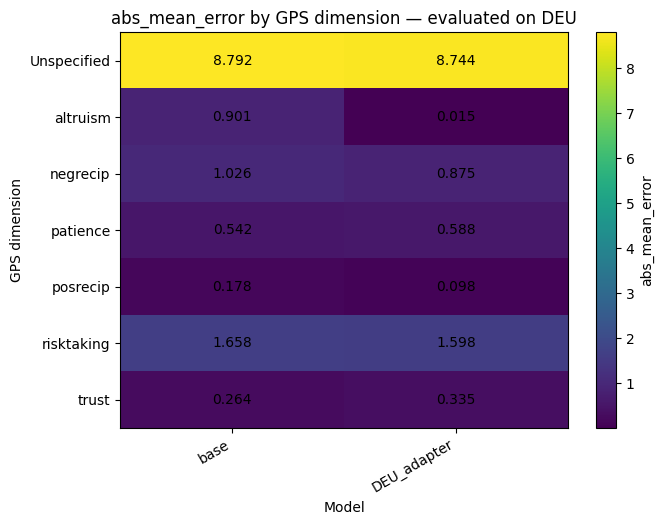

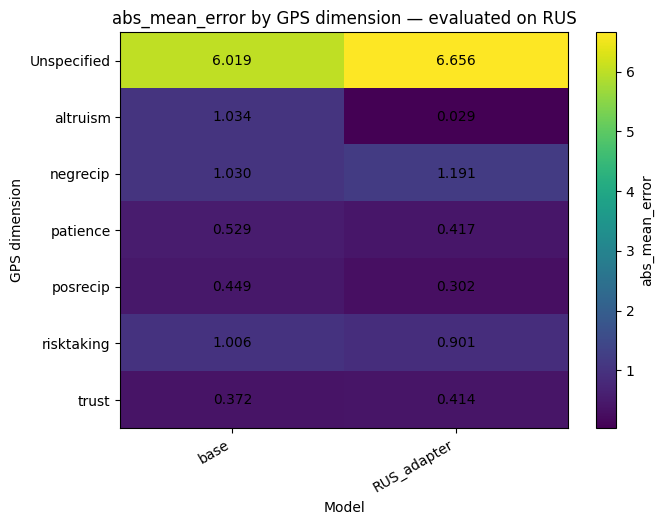

In [34]:
# ------------------------------------------------------------
# 6. Heatmaps by GPS dimension
# ------------------------------------------------------------

def plot_gps_dimension_metric_heatmaps(
    summary_df,
    metric,
    value_column="mean",
):
    metric_data = summary_df.loc[
        summary_df["metric"].eq(metric)
    ].copy()

    if metric_data.empty:
        print(f"No finite results available for {metric}.")
        return

    preferred_model_order = ["base"] + [
        f"{country}_adapter" for country in ADAPTER_COUNTRY_CODES
    ]

    available_eval_countries = [
        country
        for country in DATA_COUNTRY_CODES
        if country in set(metric_data["eval_country"].dropna())
    ]

    for eval_country in available_eval_countries:
        subset = metric_data.loc[
            metric_data["eval_country"].eq(eval_country)
        ]

        if subset.empty:
            continue

        table = subset.pivot_table(
            index="gps_dimension",
            columns="model",
            values=value_column,
            aggfunc="mean",
        )

        available_models = [
            model
            for model in preferred_model_order
            if model in table.columns
        ]
        remaining_models = [
            model
            for model in table.columns
            if model not in available_models
        ]

        table = table.reindex(
            columns=available_models + remaining_models
        ).sort_index()

        if table.empty:
            continue

        fig_height = max(4.0, 0.55 * len(table.index) + 1.5)
        fig_width = max(7.0, 1.7 * len(table.columns) + 2.5)

        fig, ax = plt.subplots(
            figsize=(fig_width, fig_height)
        )

        image = ax.imshow(
            table.to_numpy(dtype=float),
            aspect="auto",
        )

        ax.set_xticks(
            range(len(table.columns)),
            labels=table.columns,
            rotation=30,
            ha="right",
        )
        ax.set_yticks(
            range(len(table.index)),
            labels=table.index,
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("GPS dimension")
        ax.set_title(
            f"{metric} by GPS dimension — evaluated on {eval_country}"
        )

        for row_index in range(len(table.index)):
            for column_index in range(len(table.columns)):
                value = table.iloc[row_index, column_index]
                label = "NA" if pd.isna(value) else f"{value:.3f}"

                ax.text(
                    column_index,
                    row_index,
                    label,
                    ha="center",
                    va="center",
                )

        fig.colorbar(image, ax=ax, label=metric)
        plt.tight_layout()
        plt.show()


for metric_name in [
    "tv_distance",
    "js_divergence",
    "wasserstein_distance",
    "abs_mean_error",
]:
    plot_gps_dimension_metric_heatmaps(
        gps_dimension_metric_summary,
        metric=metric_name,
    )


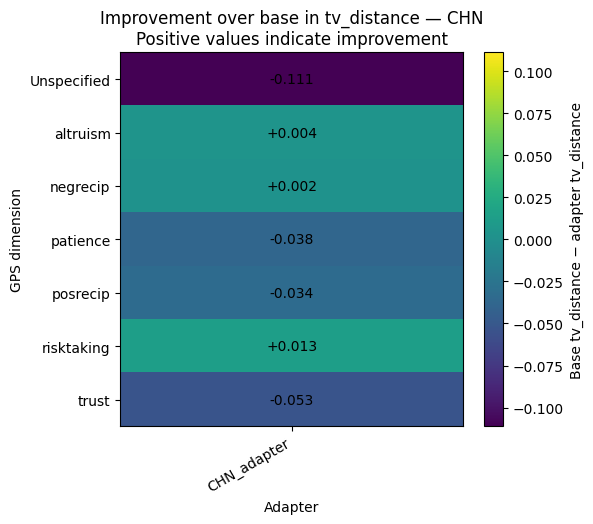

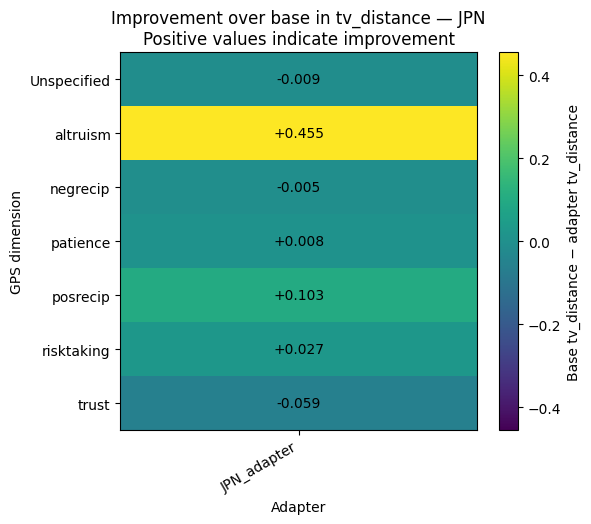

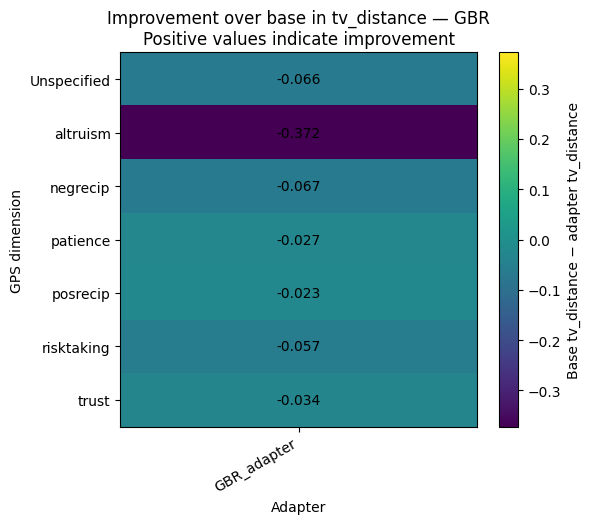

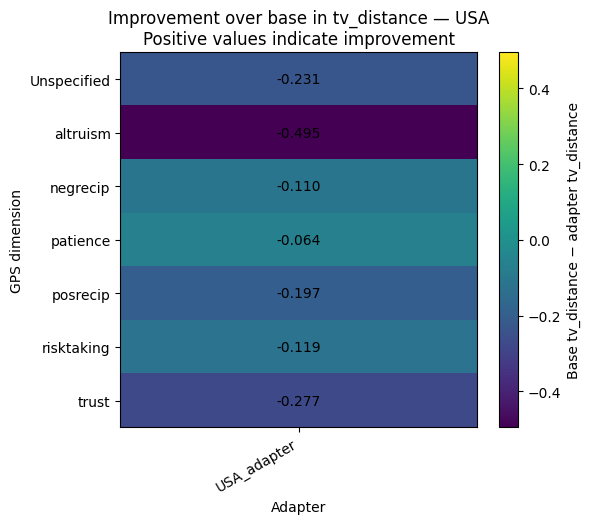

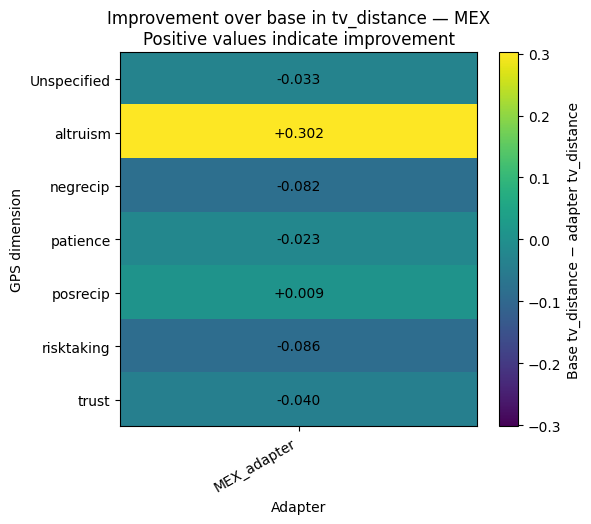

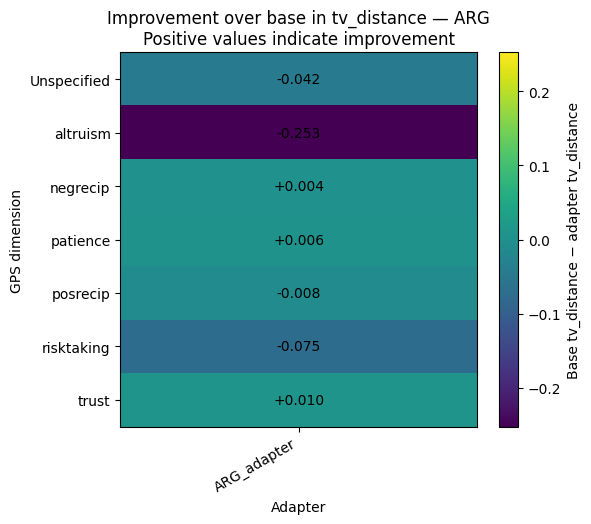

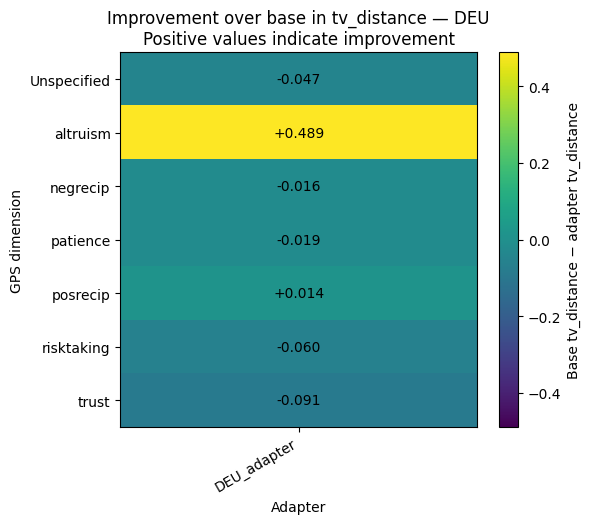

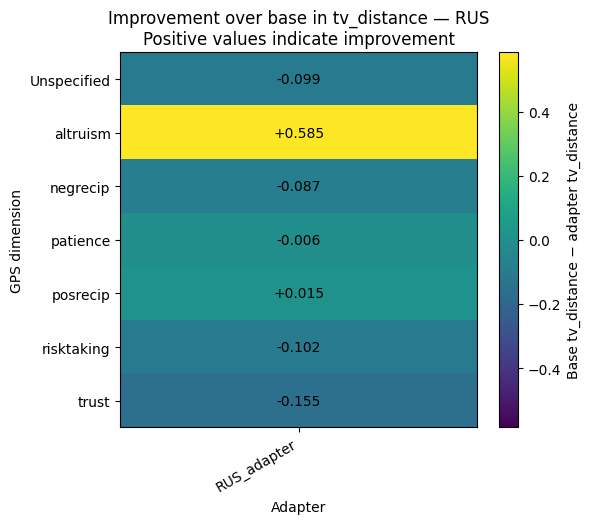

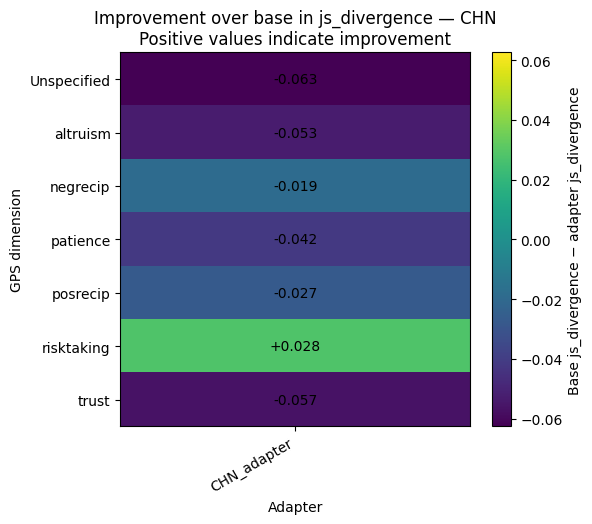

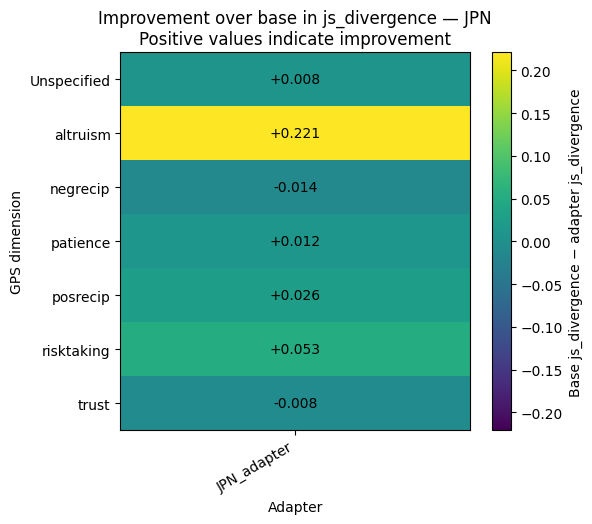

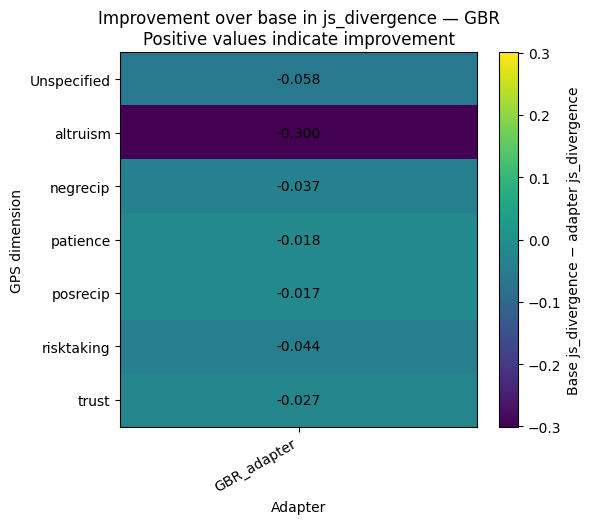

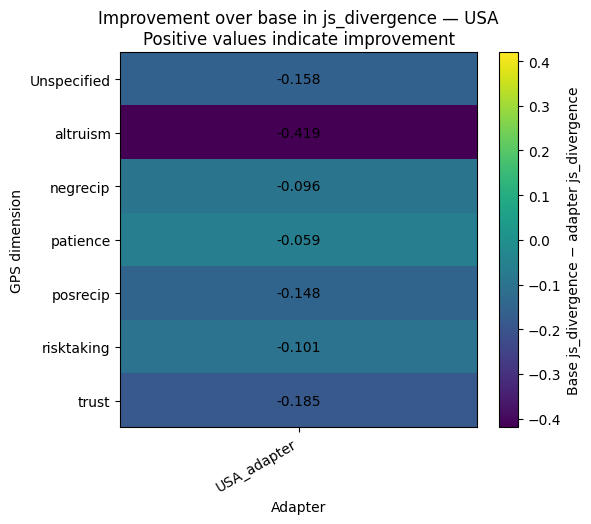

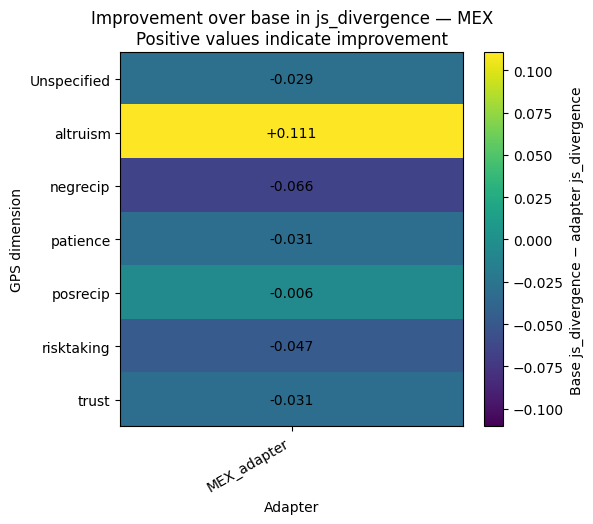

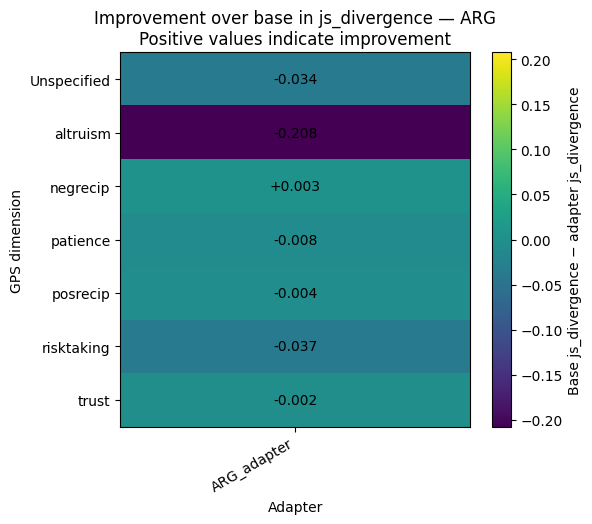

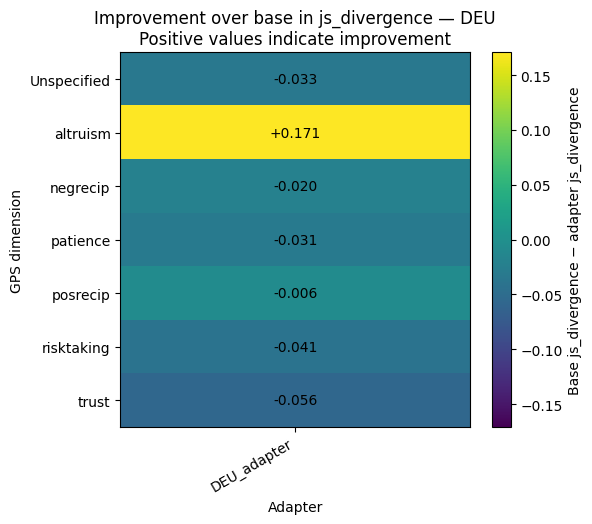

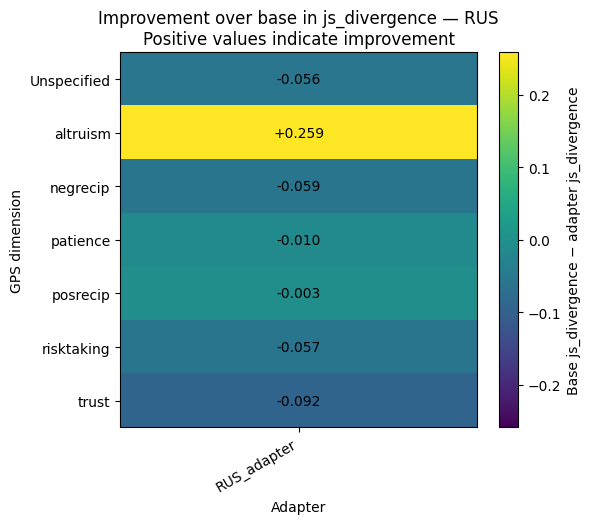

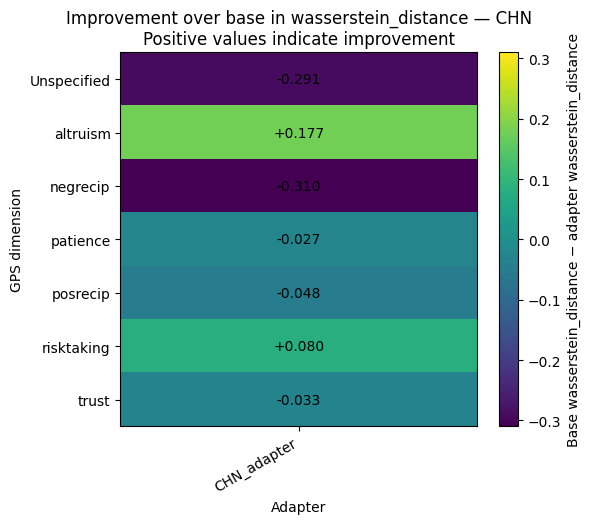

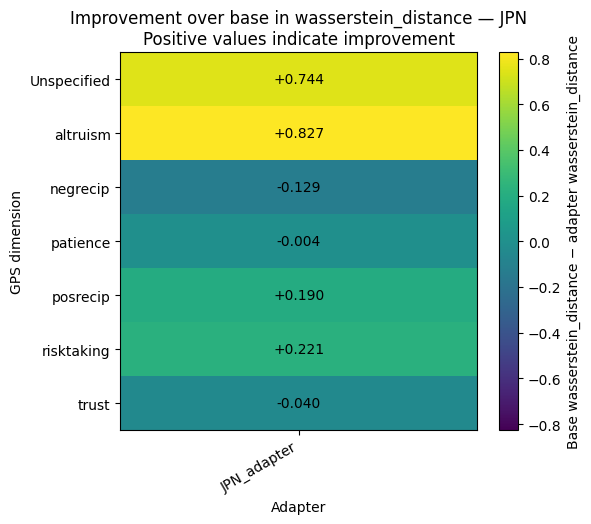

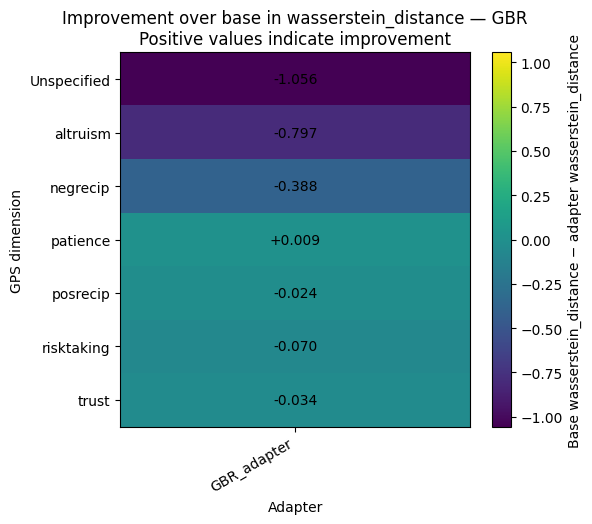

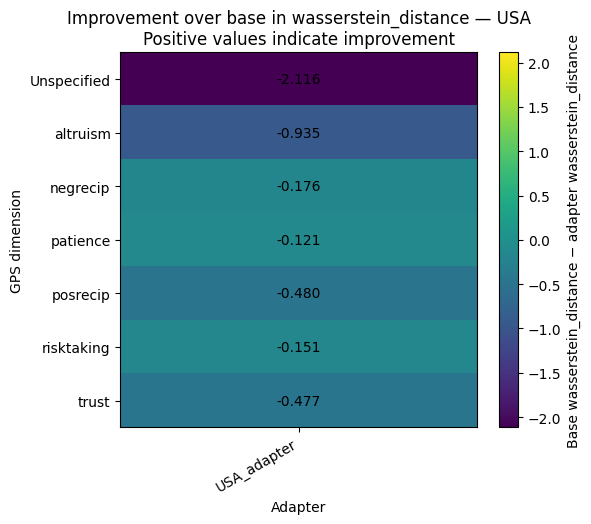

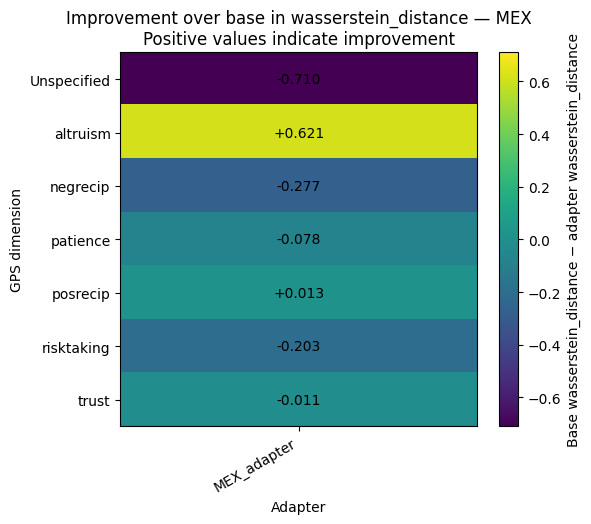

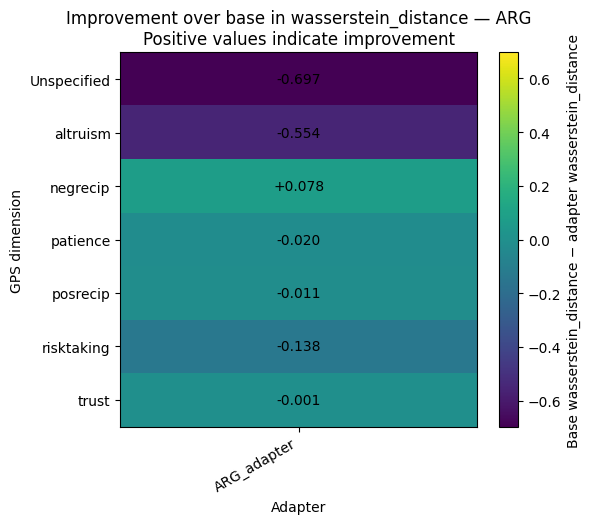

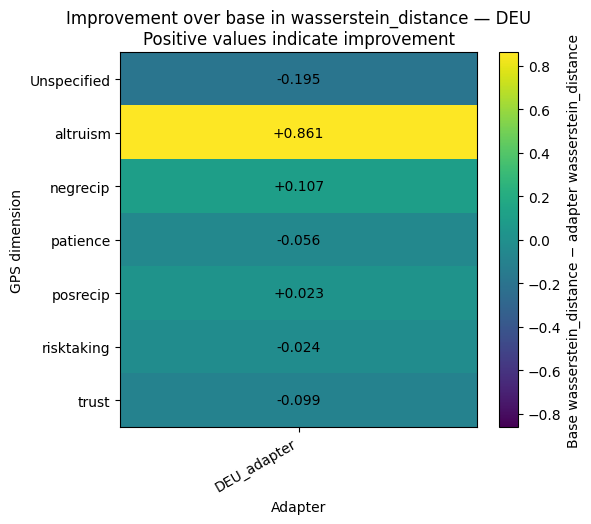

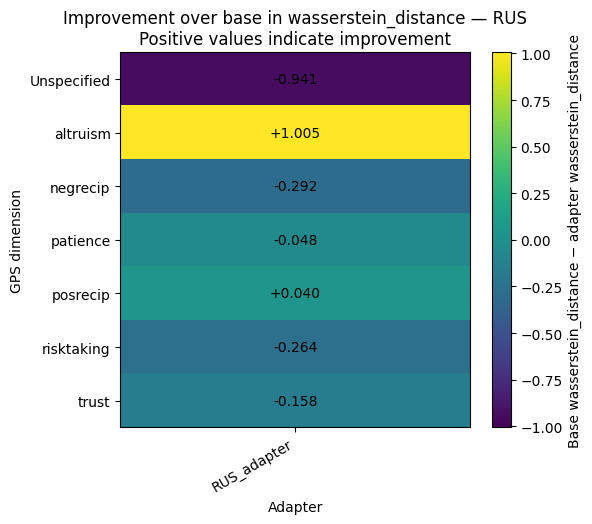

GPS-dimension analysis complete.
Results saved to: /content/drive/MyDrive/DPO/DPO/eval_new_data/eval_results_wvs_wave7_new


In [35]:
# ------------------------------------------------------------
# 7. Improvement-over-base heatmaps
# ------------------------------------------------------------

def plot_gps_improvement_heatmaps(
    improvement_summary,
    metric,
):
    subset = improvement_summary.loc[
        improvement_summary["metric"].eq(metric)
    ].copy()

    if subset.empty:
        print(f"No adapter improvement results for {metric}.")
        return

    available_eval_countries = [
        country
        for country in DATA_COUNTRY_CODES
        if country in set(subset["eval_country"].dropna())
    ]

    for eval_country in available_eval_countries:
        country_data = subset.loc[
            subset["eval_country"].eq(eval_country)
        ]

        if country_data.empty:
            continue

        table = country_data.pivot_table(
            index="gps_dimension",
            columns="model",
            values="mean_improvement_over_base",
            aggfunc="mean",
        ).sort_index()

        if table.empty:
            continue

        fig_height = max(4.0, 0.55 * len(table.index) + 1.5)
        fig_width = max(6.0, 1.8 * len(table.columns) + 2.5)

        fig, ax = plt.subplots(
            figsize=(fig_width, fig_height)
        )

        max_absolute_value = np.nanmax(
            np.abs(table.to_numpy(dtype=float))
        )

        if not np.isfinite(max_absolute_value) or max_absolute_value == 0:
            max_absolute_value = 1.0

        image = ax.imshow(
            table.to_numpy(dtype=float),
            aspect="auto",
            vmin=-max_absolute_value,
            vmax=max_absolute_value,
        )

        ax.set_xticks(
            range(len(table.columns)),
            labels=table.columns,
            rotation=30,
            ha="right",
        )
        ax.set_yticks(
            range(len(table.index)),
            labels=table.index,
        )

        ax.set_xlabel("Adapter")
        ax.set_ylabel("GPS dimension")
        ax.set_title(
            f"Improvement over base in {metric} — {eval_country}\n"
            "Positive values indicate improvement"
        )

        for row_index in range(len(table.index)):
            for column_index in range(len(table.columns)):
                value = table.iloc[row_index, column_index]
                label = "NA" if pd.isna(value) else f"{value:+.3f}"

                ax.text(
                    column_index,
                    row_index,
                    label,
                    ha="center",
                    va="center",
                )

        fig.colorbar(
            image,
            ax=ax,
            label=f"Base {metric} − adapter {metric}",
        )
        plt.tight_layout()
        plt.show()


for metric_name in [
    "tv_distance",
    "js_divergence",
    "wasserstein_distance",
]:
    plot_gps_improvement_heatmaps(
        gps_base_improvement_summary,
        metric=metric_name,
    )


print("GPS-dimension analysis complete.")
print(f"Results saved to: {RESULTS_DIR}")


## Interpretation guide

Lower values are better for all error/divergence metrics. The most important comparisons are:

1. **Adapter versus base on the same population:** positive `mean_improvement_over_base` means the adapter improved on the base model.
2. **Matched versus cross adapter:** positive `mean_cross_minus_matched` means the population's own adapter fits better than the other-country adapter.
3. **Distribution shape:** use TV/JS/Brier and calibration, not only the mean response.
4. **Ordered scales:** use Wasserstein distance plus mean and standard-deviation errors. These retain information about both central tendency and dispersion.
5. **Numeric-open questions:** exact-distribution divergence can be strict, so emphasize Wasserstein and moment errors for Q261/Q262.

The weighted population distributions, option-level model probabilities, per-question metrics, bootstrap summaries, base-model improvements, and matched-versus-cross comparisons are all written to `RESULTS_DIR`.